# CS313 — Deep Learning for AI: Final Project
## Time-series Data and Application to Stock Markets

**Student ID:** 240162

---

## Task 1 — Nasdaq Stock Price Prediction

This section covers:
- **Task 1.1** — Multi-feature extension (Low, High, Open, Close, Adj. Close, Volume)
- **Task 1.2** — Forecast the k-th day ahead
- **Task 1.3** — Forecast k consecutive days ahead

### 1.0 — Imports & Configuration

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.4.3
Pandas version: 3.0.1


### 1.1 — Data Loading & Company Selection

**Strategy:**
- Load all NASDAQ CSV files from the data folder
- Filter companies with at least **252 trading days** (~1 year) of data to ensure meaningful patterns
- Parse dates and sort chronologically — chronological order is strictly preserved throughout
- Display a summary of the loaded dataset

In [5]:
# ── Configuration ────────────────────────────────────────────────────────────
NASDAQ_DATA_DIR = '/Users/ttt/Downloads/DlFinalProject/csv/'
MIN_DATA_POINTS = 252          # at least 1 trading year
FEATURES        = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
TARGET_FEATURE  = 'Close'      # primary prediction target

# Time-series split ratios (no shuffling — strictly chronological)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15  (remainder)

print(f"Data directory : {NASDAQ_DATA_DIR}")
print(f"Features used  : {FEATURES}")
print(f"Target feature : {TARGET_FEATURE}")
print(f"Min data points: {MIN_DATA_POINTS}")

Data directory : /Users/ttt/Downloads/DlFinalProject/csv/
Features used  : ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
Target feature : Close
Min data points: 252


In [6]:
def load_nasdaq_data(data_dir: str, min_points: int = 252) -> dict[str, pd.DataFrame]:
    """
    Load all NASDAQ CSVs, parse dates, sort chronologically,
    and keep only companies with >= min_points trading days.

    Returns
    -------
    dict mapping ticker symbol -> DataFrame with columns
    [Date, Open, High, Low, Close, Adjusted Close, Volume]
    """
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    print(f"Found {len(csv_files)} CSV files in {data_dir}")

    stocks = {}
    skipped = 0

    for path in csv_files:
        ticker = os.path.splitext(os.path.basename(path))[0]  # e.g. 'AAPL'
        try:
            df = pd.read_csv(path)

            # Normalise column names (strip whitespace)
            df.columns = [c.strip() for c in df.columns]

            # Parse date — format is DD-MM-YYYY
            df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
            df.dropna(subset=['Date'], inplace=True)

            # Sort chronologically (oldest first)
            df.sort_values('Date', inplace=True)
            df.reset_index(drop=True, inplace=True)

            # Drop rows with any NaN in the price/volume columns
            required_cols = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
            df.dropna(subset=required_cols, inplace=True)

            if len(df) < min_points:
                skipped += 1
                continue

            stocks[ticker] = df

        except Exception as e:
            print(f"  WARNING: could not load {ticker}: {e}")
            skipped += 1

    print(f"Loaded  : {len(stocks)} companies (>= {min_points} data points)")
    print(f"Skipped : {skipped} companies (insufficient data or errors)")
    return stocks


nasdaq_data = load_nasdaq_data(NASDAQ_DATA_DIR, MIN_DATA_POINTS)

Found 1564 CSV files in /Users/ttt/Downloads/DlFinalProject/csv/

Loaded  : 1550 companies (>= 252 data points)
Skipped : 14 companies (insufficient data or errors)


In [7]:
# ── Dataset summary ───────────────────────────────────────────────────────────
summary_rows = []
for ticker, df in nasdaq_data.items():
    summary_rows.append({
        'Ticker'     : ticker,
        'Start Date' : df['Date'].iloc[0].date(),
        'End Date'   : df['Date'].iloc[-1].date(),
        'Data Points': len(df),
        'Years'      : round((df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.25, 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Data Points', ascending=False)
summary_df.reset_index(drop=True, inplace=True)

print(f"Total companies loaded: {len(summary_df)}")
print(f"\nTop 10 companies by data length:")
display(summary_df.head(10))

print(f"\nDistribution of historical data length:")
print(summary_df['Years'].describe().round(2))

Total companies loaded: 1550

Top 10 companies by data length:


,Ticker,Start Date,End Date,Data Points,Years
0,GT,1970-01-02,2022-12-12,13356,52.9
1,TXN,1972-06-01,2022-12-12,12744,50.5
2,OTTR,1973-02-21,2022-12-12,12564,49.8
3,KLIC,1973-02-21,2022-12-12,12564,49.8
4,SGC,1973-02-21,2022-12-12,12564,49.8
5,MSEX,1973-02-21,2022-12-12,12564,49.8
6,VLGEA,1973-02-21,2022-12-12,12564,49.8
7,DIOD,1973-02-21,2022-12-12,12564,49.8
8,ALCO,1973-05-03,2022-12-12,12514,49.6
9,PHI,1973-05-03,2022-12-12,12514,49.6



Distribution of historical data length:
count    1550.00
mean       22.10
std        10.91
min         1.00
25%        12.90
50%        22.60
75%        29.10
max        52.90
Name: Years, dtype: float64


In [8]:
# ── Inspect a sample stock (AAPL) ─────────────────────────────────────────────
sample_ticker = 'AAPL'
df_sample = nasdaq_data[sample_ticker]

print(f"Sample: {sample_ticker}")
print(f"Shape : {df_sample.shape}")
print(f"Date range: {df_sample['Date'].iloc[0].date()} → {df_sample['Date'].iloc[-1].date()}")
print()
display(df_sample.head())
print()
display(df_sample.describe().round(4))

Sample: AAPL
Shape : (10590, 7)
Date range: 1980-12-12 → 2022-12-12



,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


,Date,Low,Open,Volume,High,Close,Adjusted Close
count,10590,10590.0000,10590.0000,1.059000e+04,10590.0000,10590.0000,10590.0000
mean,2001-12-04 16:56:17.677053,16.1411,16.3240,3.279584e+08,16.5095,16.3321,15.6610
min,1980-12-12 00:00:00,0.0491,0.0497,0.000000e+00,0.0497,0.0491,0.0382
25%,1991-06-04 06:00:00,0.2801,0.2867,1.215564e+08,0.2937,0.2868,0.2372
50%,2001-11-29 12:00:00,0.4775,0.4844,2.151240e+08,0.4933,0.4844,0.4018
75%,2012-06-05 18:00:00,15.8005,16.0093,4.070262e+08,16.1792,15.9688,13.8314
max,2022-12-12 00:00:00,179.1200,182.6300,7.421641e+09,182.9400,182.0100,180.9597
std,NaN,34.4960,34.9048,3.379549e+08,35.3278,34.9285,34.5968


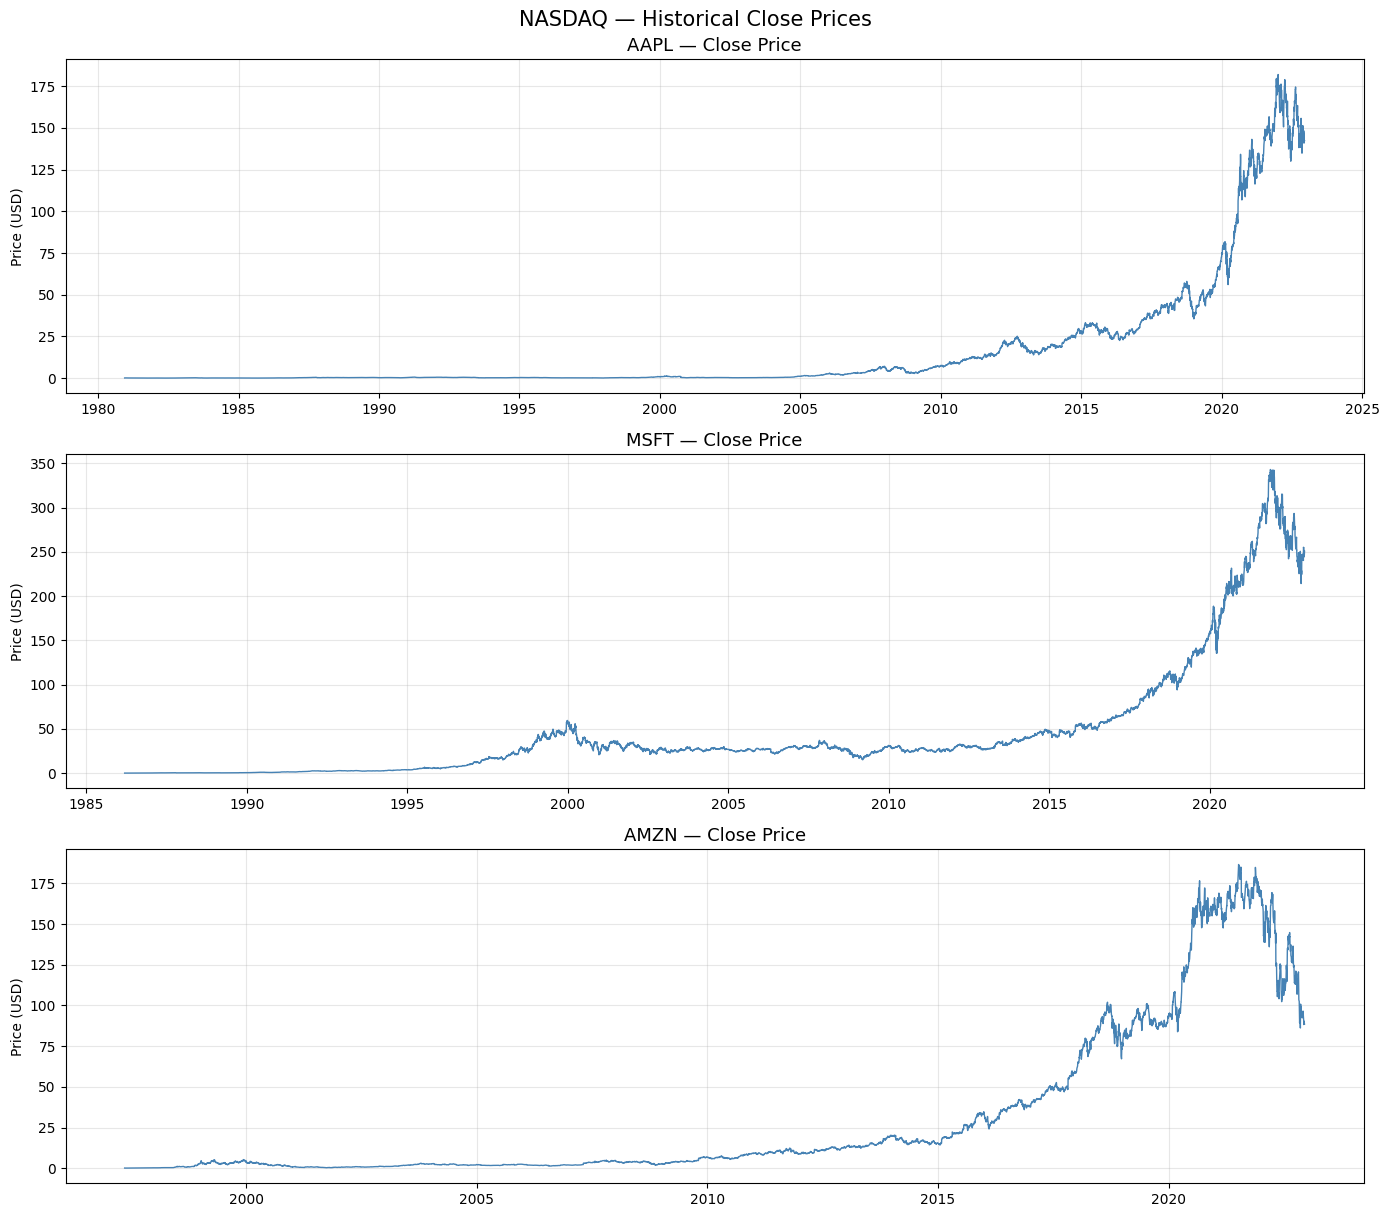

In [225]:
# ── Visualise closing price history for a few well-known stocks ───────────────
tickers_to_plot = [t for t in ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META'] if t in nasdaq_data]

fig, axes = plt.subplots(len(tickers_to_plot), 1, figsize=(14, 4 * len(tickers_to_plot)), sharex=False)
if len(tickers_to_plot) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers_to_plot):
    df_t = nasdaq_data[ticker]
    ax.plot(df_t['Date'], df_t['Close'], linewidth=1, color='steelblue')
    ax.set_title(f'{ticker} — Close Price', fontsize=13)
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('NASDAQ — Historical Close Prices', fontsize=15, y=1.01)
plt.show()

In [9]:
# ── Sector candidate pools ────────────────────────────────────────────────────
SECTOR_CANDIDATES = {
    'Technology'  : ['AAPL','MSFT','INTC','TXN','WDC','AMD','QCOM','AMAT','MU','KLAC',
                     'ADI','MRVL','NXPI','DIOD','KLIC','SMTC','FORM','COHU','ACLS','MKSI'],
    'Healthcare'  : ['AMGN','BIIB','GILD','VRTX','IDXX','HSIC','XRAY','PDCO','HOLX','ISRG',
                     'NEOG','MLAB','AMED','LMAT','ANIK','NTRA','PRGS','MDXG','CERS','NVCR'],
    'Financials'  : ['CINF','NDAQ','MORN','SEIC','WSBC','CBSH','UMBF','FFIN','BOKF','WAFD',
                     'SFNC','CVBF','MSBI','TRMK','HBAN','FBIZ','HIFS','BSVN','CBTX','SBCF'],
    'Consumer'    : ['COST','SBUX','MAT','HELE','FIZZ','JJSF','MNST','PETS','DLTR','ROST',
                     'FOXA','DISH','CAKE','BJRI','TXRH','JACK','NFLX','CHDN','ULTA','DNKN'],
    'Industrials' : ['OTTR','APOG','TRNS','FAST','ATRO','HOFT','FLXS','ARTW','TWIN','MFIN',
                     'AEIS','MTRN','DLB','ENSG','EXPO','HCKT','LAWS','MGRC','NWPX','PRIM'],
    'Energy'      : ['PTEN','REX','CLNE','TRGP','SGC','ALCO','PHI','CEIX','VAALCO','ESTE',
                     'ROCC','BATL','USAC','SRCI','WTTR','NGL','CIVI','SOI','MARPS','TPVG'],
}

TOP_N = 5

# ── Select top N per sector ───────────────────────────────────────────────────
length_lookup = summary_df.set_index('Ticker')['Data Points'].to_dict()

sector_selection = {}
all_selected     = []

for sector, candidates in SECTOR_CANDIDATES.items():
    available = [(t, length_lookup[t]) for t in candidates if t in nasdaq_data]
    available.sort(key=lambda x: x[1], reverse=True)
    top = [t for t, _ in available[:TOP_N]]
    sector_selection[sector] = top
    all_selected.extend(top)
    print(f"{sector:15s}: {top}")

# Always include AAPL as demo ticker if not already selected
if 'AAPL' not in all_selected:
    all_selected.append('AAPL')
    print(f"\nNote: AAPL added separately as demo ticker")

print(f"\nTotal selected : {len(all_selected)} stocks across {len(sector_selection)} sectors")

# Build filtered dict
nasdaq_selected = {t: nasdaq_data[t] for t in all_selected}

# Demo ticker for model development
DEMO_TICKER = 'AAPL'
df_demo = nasdaq_selected[DEMO_TICKER].copy()
print(f"\nDemo ticker : {DEMO_TICKER}")
print(f"Data points : {len(df_demo)}")
print(f"Date range  : {df_demo['Date'].iloc[0].date()} → {df_demo['Date'].iloc[-1].date()}")

Technology     : ['TXN', 'DIOD', 'KLIC', 'WDC', 'INTC']
Healthcare     : ['AMGN', 'MLAB', 'NEOG', 'HOLX', 'IDXX']
Financials     : ['CINF', 'CBSH', 'UMBF', 'TRMK', 'HBAN']
Consumer       : ['MAT', 'HELE', 'ROST', 'MNST', 'JJSF']
Industrials    : ['OTTR', 'APOG', 'TRNS', 'ATRO', 'FLXS']
Energy         : ['SGC', 'ALCO', 'PHI', 'MARPS', 'CLNE']

Note: AAPL added separately as demo ticker

Total selected : 31 stocks across 6 sectors

Demo ticker : AAPL
Data points : 10590
Date range  : 1980-12-12 → 2022-12-12


In [10]:
# ── Summary table of selected stocks ─────────────────────────────────────────
rows = []
for sector, tickers in sector_selection.items():
    for t in tickers:
        df_t = nasdaq_data[t]
        rows.append({
            'Sector'      : sector,
            'Ticker'      : t,
            'Start Date'  : df_t['Date'].iloc[0].date(),
            'End Date'    : df_t['Date'].iloc[-1].date(),
            'Data Points' : len(df_t),
            'Years'       : round((df_t['Date'].iloc[-1] - df_t['Date'].iloc[0]).days / 365.25, 1),
        })

selection_df = pd.DataFrame(rows)
display(selection_df)

print(f"\nAverage years of data per sector:")
print(selection_df.groupby('Sector')['Years'].mean().round(1))

,Sector,Ticker,Start Date,End Date,Data Points,Years
0,Technology,TXN,1972-06-01,2022-12-12,12744,50.5
1,Technology,DIOD,1973-02-21,2022-12-12,12564,49.8
2,Technology,KLIC,1973-02-21,2022-12-12,12564,49.8
3,Technology,WDC,1978-10-31,2022-12-12,11125,44.1
4,Technology,INTC,1980-03-17,2022-12-12,10778,42.7
5,Healthcare,AMGN,1983-06-17,2022-12-12,9955,39.5
6,Healthcare,MLAB,1984-02-29,2022-12-12,9778,38.8
7,Healthcare,NEOG,1989-08-23,2022-12-12,8392,33.3
8,Healthcare,HOLX,1990-03-01,2022-12-12,8261,32.8
9,Healthcare,IDXX,1991-06-21,2022-12-12,7930,31.5



Average years of data per sector:
Sector
Consumer       40.8
Energy         41.5
Financials     42.7
Healthcare     35.2
Industrials    46.0
Technology     47.4
Name: Years, dtype: float64


### 1.3 — Extend Data to 2026 via yfinance

Extend each selected ticker from **2005-01-01 to 2026-01-01** using Yahoo Finance.
- Provides ~21 years of data including recent market events
- Falls back to CSV data if a ticker fails to download
- Aligns all stocks to the same date window for consistent training

In [11]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])
import yfinance as yf
print(f"yfinance version: {yf.__version__}")

yfinance version: 1.2.0


In [13]:
DATA_START = '2005-01-01'
DATA_END   = '2026-03-31'

def fetch_yfinance(ticker: str, start: str, end: str) -> pd.DataFrame | None:
    """
    Download OHLCV data from Yahoo Finance and normalise column names
    to match the CSV format: Date, Open, High, Low, Close, Adjusted Close, Volume
    """
    try:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        if raw.empty:
            return None

        # Flatten MultiIndex columns if present
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = [col[0] for col in raw.columns]

        raw = raw.rename(columns={'Adj Close': 'Adjusted Close'})
        raw = raw[['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']]
        raw.index.name = 'Date'
        raw = raw.reset_index()
        raw['Date'] = pd.to_datetime(raw['Date'])
        raw.sort_values('Date', inplace=True)
        raw.dropna(inplace=True)
        raw.reset_index(drop=True, inplace=True)
        return raw
    except Exception as e:
        print(f"  ERROR fetching {ticker}: {e}")
        return None


def extend_with_yfinance(selected_tickers: list,
                         csv_data: dict,
                         start: str,
                         end: str) -> dict:
    """
    For each ticker:
      1. Download full history from Yahoo Finance (start → end)
      2. Fall back to CSV data if download fails
    """
    extended = {}
    failed   = []

    for ticker in selected_tickers:
        df_yf = fetch_yfinance(ticker, start, end)

        if df_yf is not None and len(df_yf) > 252:
            extended[ticker] = df_yf
        else:
            # Fallback: clip CSV data to the same window
            if ticker in csv_data:
                df_csv = csv_data[ticker].copy()
                df_csv = df_csv[df_csv['Date'] >= pd.Timestamp(start)]
                df_csv = df_csv[df_csv['Date'] <  pd.Timestamp(end)]
                df_csv.reset_index(drop=True, inplace=True)
                if len(df_csv) > 252:
                    extended[ticker] = df_csv
                    print(f"  {ticker}: yfinance failed — using CSV fallback")
                else:
                    failed.append(ticker)
                    print(f"  {ticker}: skipped — insufficient data after fallback")
            else:
                failed.append(ticker)
                print(f"  {ticker}: skipped — no data available")

    print(f"\nSuccessfully loaded : {len(extended)} tickers")
    if failed:
        print(f"Failed              : {failed}")
    return extended


print(f"Downloading {len(all_selected)} tickers from {DATA_START} to {DATA_END} ...")
print("This may take ~1–2 minutes.\n")

nasdaq_extended = extend_with_yfinance(all_selected, nasdaq_data, DATA_START, DATA_END)

This may take ~1–2 minutes.


Successfully loaded : 31 tickers


In [14]:
# ── Verify extended data ──────────────────────────────────────────────────────
rows = []
for sector, tickers in sector_selection.items():
    for t in tickers:
        if t not in nasdaq_extended:
            continue
        df_t = nasdaq_extended[t]
        rows.append({
            'Sector'      : sector,
            'Ticker'      : t,
            'Start Date'  : df_t['Date'].iloc[0].date(),
            'End Date'    : df_t['Date'].iloc[-1].date(),
            'Data Points' : len(df_t),
            'Years'       : round((df_t['Date'].iloc[-1] - df_t['Date'].iloc[0]).days / 365.25, 1),
        })

extended_df = pd.DataFrame(rows)
display(extended_df)

# Update demo dataframe
df_demo = nasdaq_extended['AAPL'].copy()
print(f"\nAAPL — {df_demo['Date'].iloc[0].date()} → {df_demo['Date'].iloc[-1].date()}")
print(f"Data points: {len(df_demo)}")
display(df_demo.tail())

,Sector,Ticker,Start Date,End Date,Data Points,Years
0,Technology,TXN,2005-01-03,2026-03-30,5343,21.2
1,Technology,DIOD,2005-01-03,2026-03-30,5343,21.2
2,Technology,KLIC,2005-01-03,2026-03-30,5343,21.2
3,Technology,WDC,2005-01-03,2026-03-30,5343,21.2
4,Technology,INTC,2005-01-03,2026-03-30,5343,21.2
5,Healthcare,AMGN,2005-01-03,2026-03-30,5343,21.2
6,Healthcare,MLAB,2005-01-03,2026-03-30,5343,21.2
7,Healthcare,NEOG,2005-01-03,2026-03-30,5343,21.2
8,Healthcare,HOLX,2005-01-03,2026-03-30,5343,21.2
9,Healthcare,IDXX,2005-01-03,2026-03-30,5343,21.2



AAPL — 2005-01-03 → 2026-03-30
Data points: 5343


,Date,Open,High,Low,Close,Adjusted Close,Volume
5338,2026-03-24,250.350006,254.830002,249.550003,251.639999,251.639999,45152300
5339,2026-03-25,254.100006,255.000000,251.600006,252.619995,252.619995,28476700
5340,2026-03-26,252.119995,257.000000,250.770004,252.889999,252.889999,41796700
5341,2026-03-27,253.899994,255.490005,248.070007,248.800003,248.800003,47900000
5342,2026-03-30,250.070007,250.869995,245.509995,246.630005,246.630005,39446200


## Task 1.1 — Multi-Feature LSTM: Next-Day Stock Price Prediction

**Pipeline:**
1. Feature engineering — technical indicators (RSI, MACD, Bollinger Bands, ATR, OBV, SMA/EMA, momentum, volatility)
2. Preprocessing — RobustScaler on features, MinMaxScaler on target, 60-day lookback sequences
3. Chronological 70 / 15 / 15 train / val / test split (no data leakage)
4. Walk-forward cross-validation (5 expanding folds) on training set
5. Stacked LSTM (128 → 64 → 32 units) with Dropout + Huber loss
6. Evaluation on AAPL: MAE, MSE, RMSE, MAPE vs naive baseline

In [97]:
# ── 1.1.1  Feature Engineering — Stationary Technical Indicators ──────────────
#
# ROOT CAUSE OF POOR PERFORMANCE (original):
#   Raw prices (SMA, EMA, Close, OBV…) are non-stationary. AAPL was ~$5 in 2005,
#   ~$80 in 2019, ~$180 in 2022. A model trained on 2005-2019 sees inputs that are
#   completely out-of-distribution when evaluated on 2023-2026 → systematic
#   underprediction of ~100-200 USD.
#
# FIX: All features expressed as bounded ratios, log-returns, or oscillators
#      that are invariant to the absolute price level.

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

LOOKBACK    = 60    # 60 trading days (~3 months)
BATCH_SIZE  = 32
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15


def add_technical_indicators(df):
    """
    Compute 20 stationary / scale-invariant technical indicators.
    NO raw prices, raw volumes, or level-dependent series are kept.
    """
    df = df.copy().reset_index(drop=True)
    close  = df['Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']
    c_safe = close.replace(0, float('nan'))

    # ── Moving averages (used only to compute ratios) ─────────────────────────
    sma10 = close.rolling(10).mean()
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    ema10 = close.ewm(span=10, adjust=False).mean()
    ema20 = close.ewm(span=20, adjust=False).mean()

    df['SMA10_vs_SMA20'] = sma10 / sma20.replace(0, float('nan')) - 1
    df['SMA20_vs_SMA50'] = sma20 / sma50.replace(0, float('nan')) - 1
    df['EMA10_vs_EMA20'] = ema10 / ema20.replace(0, float('nan')) - 1
    df['Close_vs_SMA20'] = close / sma20.replace(0, float('nan')) - 1
    df['Close_vs_SMA50'] = close / sma50.replace(0, float('nan')) - 1

    # ── RSI 14 (bounded 0-100) ────────────────────────────────────────────────
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta).clip(lower=0).rolling(14).mean()
    rs    = gain / loss.replace(0, float('nan'))
    df['RSI_14'] = 100 - (100 / (1 + rs))

    # ── MACD normalised by Close (scale-free) ─────────────────────────────────
    ema12       = close.ewm(span=12, adjust=False).mean()
    ema26       = close.ewm(span=26, adjust=False).mean()
    macd_line   = ema12 - ema26
    macd_signal = macd_line.ewm(span=9, adjust=False).mean()
    macd_hist   = macd_line - macd_signal
    df['MACD_pct']      = macd_line   / c_safe
    df['MACD_sig_pct']  = macd_signal / c_safe
    df['MACD_hist_pct'] = macd_hist   / c_safe

    # ── Bollinger Bands (already relative) ────────────────────────────────────
    bb_mid   = close.rolling(20).mean()
    bb_std   = close.rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    bb_range = (bb_upper - bb_lower).replace(0, float('nan'))
    df['BB_width'] = bb_range / bb_mid.replace(0, float('nan'))
    df['BB_pct']   = (close - bb_lower) / bb_range

    # ── ATR as % of price ─────────────────────────────────────────────────────
    tr    = pd.concat([high - low,
                       (high - close.shift(1)).abs(),
                       (low  - close.shift(1)).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14).mean()
    df['ATR_pct'] = atr14 / c_safe

    # ── Log-return volatility (already scale-free) ────────────────────────────
    log_ret             = np.log(close / close.shift(1))
    df['Volatility_10'] = log_ret.rolling(10).std()
    df['Volatility_20'] = log_ret.rolling(20).std()

    # ── Price momentum as log-returns ─────────────────────────────────────────
    df['Return_1d']  = log_ret
    df['Return_5d']  = np.log(close / close.shift(5))
    df['Return_10d'] = np.log(close / close.shift(10))
    df['Return_20d'] = np.log(close / close.shift(20))

    # ── Volume relative to its 20-day mean ───────────────────────────────────
    vol_ma20           = volume.rolling(20).mean().replace(0, float('nan'))
    df['Volume_ratio'] = volume / vol_ma20

    # ── Daily range as % of close ─────────────────────────────────────────────
    df['High_Low_pct'] = (high - low) / c_safe

    return df


FEATURE_COLS = [
    'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d',
    'SMA10_vs_SMA20', 'SMA20_vs_SMA50', 'EMA10_vs_EMA20',
    'Close_vs_SMA20', 'Close_vs_SMA50',
    'RSI_14',
    'MACD_pct', 'MACD_sig_pct', 'MACD_hist_pct',
    'BB_width', 'BB_pct',
    'ATR_pct',
    'Volatility_10', 'Volatility_20',
    'Volume_ratio',
    'High_Low_pct',
]
N_FEATURES = len(FEATURE_COLS)
print(f"Feature set: {N_FEATURES} stationary features")
for f in FEATURE_COLS:
    print(f"  • {f}")


Feature set: 20 stationary features
  • Return_1d
  • Return_5d
  • Return_10d
  • Return_20d
  • SMA10_vs_SMA20
  • SMA20_vs_SMA50
  • EMA10_vs_EMA20
  • Close_vs_SMA20
  • Close_vs_SMA50
  • RSI_14
  • MACD_pct
  • MACD_sig_pct
  • MACD_hist_pct
  • BB_width
  • BB_pct
  • ATR_pct
  • Volatility_10
  • Volatility_20
  • Volume_ratio
  • High_Low_pct


In [98]:
# ── 1.1.2  Preprocessing — Log-Return Target, Train-Only Scalers ─────────────
#
# KEY DESIGN CHOICES (all leakage-free):
#   1. TARGET: log(P[t+1]/P[t]) — stationary; prices reconstructed at eval time.
#   2. StandardScaler fit ONLY on training rows to prevent statistical leakage.
#   3. Strict chronological 70/15/15 split before any scaling or sequencing.
#   4. Scaler boundary = n_train + LOOKBACK - 1  (last X-context row in training).

def preprocess_ticker(df, lookback=LOOKBACK, target_col='Close'):
    """
    Pipeline (no data leakage):
      1. Add stationary technical indicators
      2. Compute log-return target  log(P[t+1]/P[t])
      3. Determine chronological split boundaries on raw row indices
      4. Fit StandardScaler on TRAINING rows only [0, n_train+lookback-1)
      5. Build sliding-window sequences (X, y) for each split
    """
    df_feat = add_technical_indicators(df)

    close      = df_feat[target_col]
    log_return = np.log(close.shift(-1) / close)   # next-day log return (target)
    df_feat['_target'] = log_return

    required = FEATURE_COLS + ['_target', target_col]
    df_feat  = df_feat.dropna(subset=required).reset_index(drop=True)

    dates    = df_feat['Date'].values
    X_raw    = df_feat[FEATURE_COLS].values.astype('float32')
    y_logret = df_feat['_target'].values.astype('float32')
    y_close  = df_feat[target_col].values.astype('float32')

    # ── Chronological split on raw rows ───────────────────────────────────────
    # n = number of usable (X, y) sequences
    n       = len(X_raw) - lookback
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    n_test  = n - n_train - n_val

    # Training X-context rows span [0, n_train + lookback - 1).
    #   Last training sequence (index n_train-1):
    #     X = rows[n_train-1 : n_train-1+lookback]
    #     Max X row = n_train + lookback - 2
    #   → scaler boundary = n_train + lookback - 1  (exclusive upper bound)
    train_row_end = n_train + lookback - 1   # FIX: was n_train+lookback (off-by-1)

    # ── Fit scalers on TRAINING rows only ────────────────────────────────────
    scaler_X = StandardScaler()
    scaler_X.fit(X_raw[:train_row_end])

    scaler_y = StandardScaler()
    # y targets in training span rows [lookback, n_train+lookback]; include all
    scaler_y.fit(y_logret[:n_train + lookback].reshape(-1, 1))

    X_scaled = scaler_X.transform(X_raw)
    y_scaled = scaler_y.transform(y_logret.reshape(-1, 1)).flatten()

    # ── Build sliding-window sequences ────────────────────────────────────────
    X_seq, y_seq, close_seq, date_seq = [], [], [], []
    for i in range(n):
        X_seq.append(X_scaled[i : i + lookback])
        y_seq.append(y_scaled[i + lookback])
        close_seq.append(y_close[i + lookback - 1])   # today's actual close
        date_seq.append(dates[i + lookback])

    X_seq     = np.array(X_seq,     dtype='float32')
    y_seq     = np.array(y_seq,     dtype='float32')
    close_seq = np.array(close_seq, dtype='float32')
    date_seq  = np.array(date_seq)

    slices = {
        'train': slice(0,               n_train),
        'val'  : slice(n_train,         n_train + n_val),
        'test' : slice(n_train + n_val, n),
    }
    data = {'feature_cols': FEATURE_COLS, 'scaler_X': scaler_X, 'scaler_y': scaler_y,
            'n_train': n_train, 'n_val': n_val, 'n_test': n_test}
    for split, sl in slices.items():
        data[f'X_{split}']     = X_seq[sl]
        data[f'y_{split}']     = y_seq[sl]
        data[f'close_{split}'] = close_seq[sl]
        data[f'dates_{split}'] = date_seq[sl]
    return data


def print_split_summary(data, ticker):
    """Print date ranges and verify no temporal overlap between splits."""
    print(f"\n{ticker} split summary (lookback={LOOKBACK}, features={N_FEATURES}):")
    boundaries = {}
    for split in ('train', 'val', 'test'):
        dates = data[f'dates_{split}']
        n     = data[f'n_{split}']
        d0    = pd.Timestamp(dates[0]).date()
        d1    = pd.Timestamp(dates[-1]).date()
        boundaries[split] = (d0, d1)
        print(f"  {split:5s}: {n:5d} samples  [{d0} \u2192 {d1}]")

    # Leakage audit: verify strict temporal ordering
    assert boundaries['train'][1] < boundaries['val'][0],   "LEAKAGE: train/val overlap!"
    assert boundaries['val'][1]   < boundaries['test'][0],  "LEAKAGE: val/test overlap!"
    print("  \u2713 Leakage audit passed — splits are strictly chronological, no temporal overlap.")


print("Preprocessing AAPL (demo ticker) ...")
aapl_data = preprocess_ticker(nasdaq_extended['AAPL'])
print_split_summary(aapl_data, 'AAPL')
print(f"\nShapes — X_train: {aapl_data['X_train'].shape}, "
      f"X_val: {aapl_data['X_val'].shape}, X_test: {aapl_data['X_test'].shape}")

train_lr = aapl_data['scaler_y'].inverse_transform(
    aapl_data['y_train'].reshape(-1,1)).flatten()
print(f"\nTrain log-returns: mean={train_lr.mean():.5f}  std={train_lr.std():.4f}  "
      f"min={train_lr.min():.4f}  max={train_lr.max():.4f}")


Preprocessing AAPL (demo ticker) ...

AAPL split summary (lookback=60, features=20):
  train:  3663 samples  [2005-06-09 → 2019-12-26]
  val  :   784 samples  [2019-12-27 → 2023-02-07]
  test :   786 samples  [2023-02-08 → 2026-03-27]
  ✓ Leakage audit passed — splits are strictly chronological, no temporal overlap.

Shapes — X_train: (3663, 60, 20), X_val: (784, 60, 20), X_test: (786, 60, 20)

Train log-returns: mean=0.00109  std=0.0201  min=-0.1975  max=0.1302


In [99]:
# ── 1.1.3  LSTM Model Architecture (anti-overfit version) ────────────────────
#
# Changes vs original:
#   • Dropout 0.2 → 0.3 (val loss was 250x train loss — severe overfitting)
#   • L2 regularisation on LSTM kernel + recurrent kernel
#   • Gradient clipping kept (clipnorm=1.0)
#   • Huber loss predicts StandardScaled log-returns (δ=1.0 covers ±1σ well)

from tensorflow.keras.regularizers import l2


def build_lstm_model(n_features=N_FEATURES, lookback=LOOKBACK):
    """
    Stacked LSTM: 128 → 64 → 32 units with Dropout(0.3) + L2 regularisation.
    Input  : (batch, lookback=60, n_features=20) — StandardScaled features
    Output : scalar — next-day log-return (StandardScaled)
    """
    model = Sequential([
        LSTM(128, return_sequences=True,
             input_shape=(lookback, n_features),
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        Dropout(0.3),
        LSTM(64, return_sequences=True,
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        Dropout(0.3),
        LSTM(32, return_sequences=False,
             kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1),
    ], name='LSTM_StockPredictor_v2')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae'],
    )
    return model


demo_model = build_lstm_model()
demo_model.summary()
del demo_model
tf.keras.backend.clear_session()


Model: "LSTM_StockPredictor_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,657 (541.63 KB)

 Trainable params: 138,657 (541.63 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
# ── 1.1.4  Walk-Forward Cross-Validation ─────────────────────────────────────
#
# Why walk-forward?
#   Standard k-fold would leak future data into training (train on 2020, test on 2010).
#   Walk-forward uses an expanding window: each fold trains on [0 … t] and
#   validates on [t+1 … t+k], preserving causal ordering.
#
# We use sklearn's TimeSeriesSplit which implements this automatically.

def walk_forward_cv(X_train: np.ndarray,
                    y_train: np.ndarray,
                    n_splits: int = 5) -> pd.DataFrame:
    """
    Walk-forward cross-validation on the training set.
    Trains a fresh LSTM per fold (10 epochs max for speed).
    Reports scaled MAE/RMSE per fold.
    """
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    results = []

    print(f"Walk-forward CV — {n_splits} folds on training set "
          f"({len(X_train)} samples)\n")

    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train), 1):
        X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
        X_vl, y_vl = X_train[vl_idx], y_train[vl_idx]

        if len(X_tr) < 200:          # skip trivially small folds
            continue

        tf.keras.backend.clear_session()
        np.random.seed(42); tf.random.set_seed(42)

        m = build_lstm_model()
        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=0)
        m.fit(X_tr, y_tr,
              validation_data=(X_vl, y_vl),
              epochs=25, batch_size=BATCH_SIZE,
              callbacks=[es], verbose=0)

        y_pred = m.predict(X_vl, verbose=0).flatten()
        mae    = mean_absolute_error(y_vl, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_vl, y_pred))

        results.append({'Fold': fold, 'Train N': len(X_tr),
                        'Val N': len(X_vl), 'MAE': mae, 'RMSE': rmse})
        print(f"  Fold {fold}:  train={len(X_tr):4d}  val={len(X_vl):3d}  "
              f"MAE={mae:.4f}  RMSE={rmse:.4f}")

        del m

    tf.keras.backend.clear_session()
    np.random.seed(42); tf.random.set_seed(42)

    cv_df = pd.DataFrame(results)
    print(f"\n  Mean  MAE : {cv_df['MAE'].mean():.4f}  ± {cv_df['MAE'].std():.4f}")
    print(f"  Mean  RMSE: {cv_df['RMSE'].mean():.4f}  ± {cv_df['RMSE'].std():.4f}")
    return cv_df


cv_results = walk_forward_cv(aapl_data['X_train'], aapl_data['y_train'], n_splits=5)
display(cv_results)

Walk-forward CV — 5 folds on training set (3663 samples)

  Fold 1:  train= 613  val=610  MAE=1.0067  RMSE=1.4031
  Fold 2:  train=1223  val=610  MAE=0.6235  RMSE=0.8388
  Fold 3:  train=1833  val=610  MAE=0.5966  RMSE=0.8421
  Fold 4:  train=2443  val=610  MAE=0.5067  RMSE=0.7194
  Fold 5:  train=3053  val=610  MAE=0.5789  RMSE=0.8178

  Mean  MAE : 0.6625  ± 0.1972
  Mean  RMSE: 0.9242  ± 0.2723


,Fold,Train N,Val N,MAE,RMSE
0,1,613,610,1.006723,1.403092
1,2,1223,610,0.623546,0.838801
2,3,1833,610,0.596550,0.842087
3,4,2443,610,0.506711,0.719380
4,5,3053,610,0.578948,0.817755


Building and training LSTM on AAPL ...

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.4137 - mae: 0.6999 - val_loss: 0.5034 - val_mae: 0.8220 - learning_rate: 0.0010
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.4006 - mae: 0.6960 - val_loss: 0.4921 - val_mae: 0.8177 - learning_rate: 0.0010
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.3928 - mae: 0.6955 - val_loss: 0.4856 - val_mae: 0.8172 - learning_rate: 0.0010
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.3868 - mae: 0.6944 - val_loss: 0.4809 - val_mae: 0.8173 - learning_rate: 0.0010
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.3823 - mae: 0.6940 - val_loss: 0.4775 - val_mae: 0.8173 - learning_rate: 0.0010
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.3799 - mae: 0.6953 - val_loss: 0.4749 - val_mae: 0.8174 - learning_rate: 0.0010
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.3771 - mae: 0.6945 - val_loss: 0

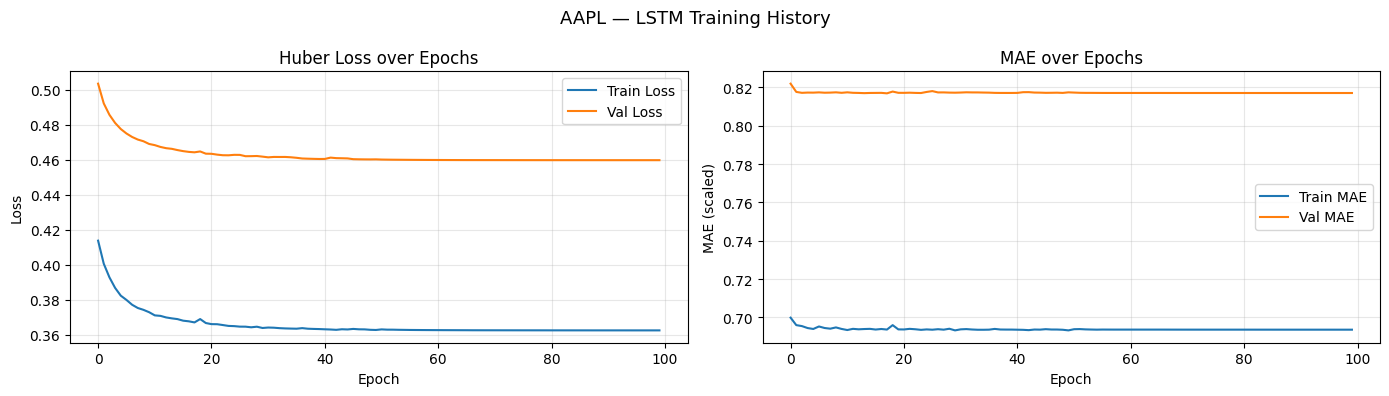


Best val_loss epoch: 100


In [101]:
# ── 1.1.5  Full Training on AAPL ─────────────────────────────────────────────
#
# Train on 70 % of AAPL history (2005 → ~2019), validate on next 15 % (~2019–2021).
# EarlyStopping halts when val_loss stops improving (patience=15).
# ReduceLROnPlateau halves lr when val_loss plateaus (patience=7).

print("Building and training LSTM on AAPL ...\n")
tf.keras.backend.clear_session()
np.random.seed(42); tf.random.set_seed(42)

model_aapl = build_lstm_model()

callbacks_full = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history = model_aapl.fit(
    aapl_data['X_train'], aapl_data['y_train'],
    validation_data=(aapl_data['X_val'], aapl_data['y_val']),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_full,
    verbose=1,
)

# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Huber Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('AAPL — LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest val_loss epoch: {np.argmin(history.history['val_loss']) + 1}")

AAPL — LSTM Prediction Metrics (USD prices, reconstructed from log returns)


,Split,MAE,MSE,RMSE,MAPE
0,Validation,2.0723,7.7397,2.7820,1.66%
1,Test,2.2692,11.3241,3.3651,1.08%


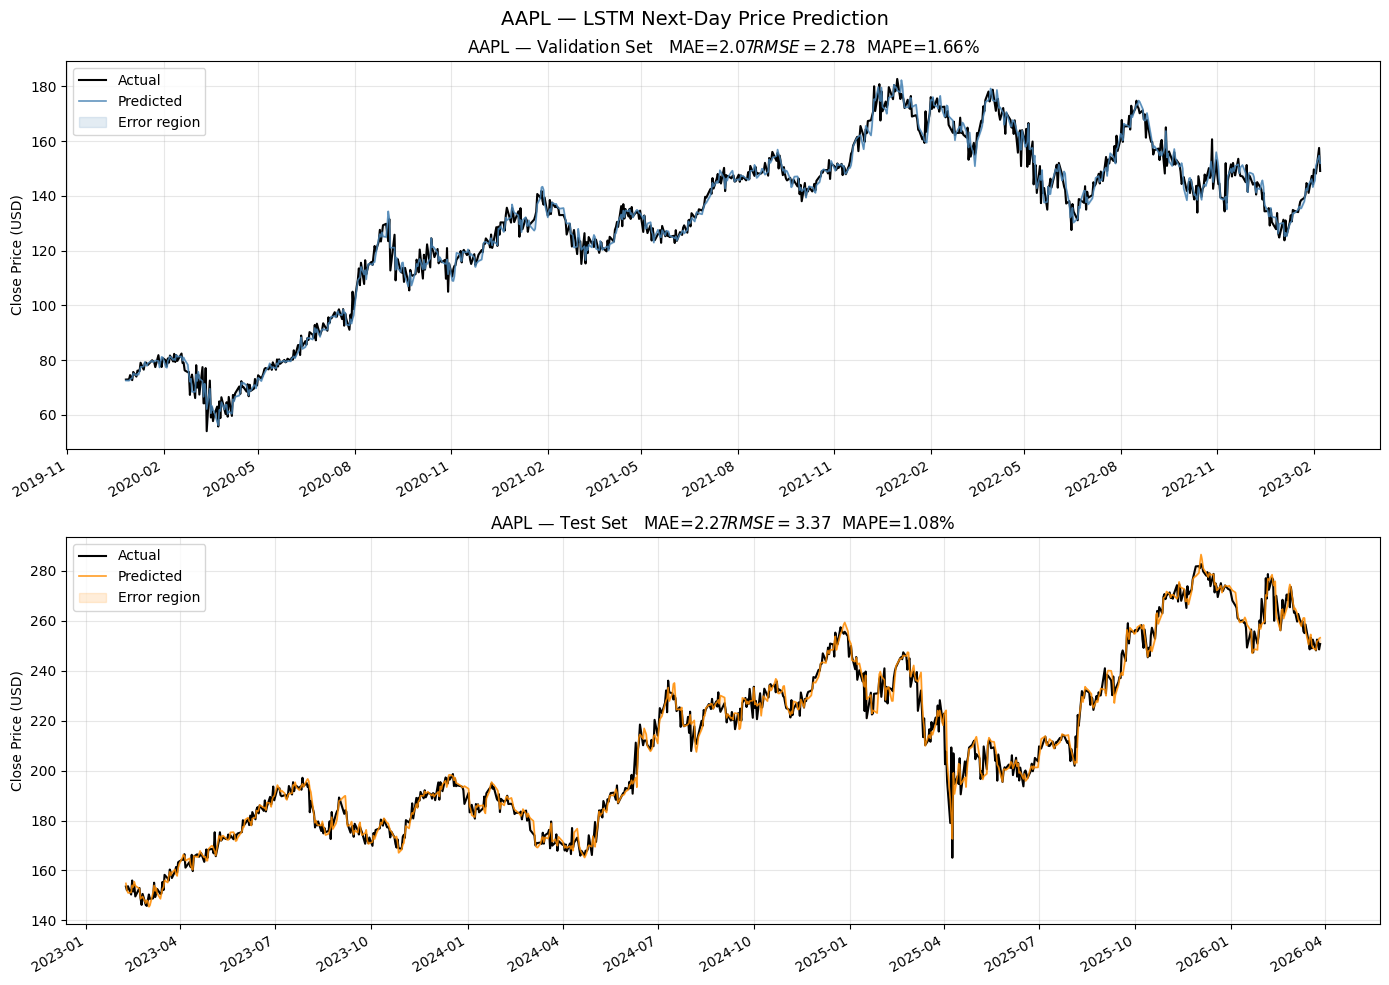

In [103]:
# ── 1.1.6  Evaluation — Price Reconstruction from Log Returns ────────────────
#
# Reconstruction:  P_pred[t+1] = P_actual[t] * exp(log_return_pred)
# Uses today's actual close as the base so errors do not accumulate.

def evaluate_split(model, data, split):
    """
    Predict next-day log return, inverse-transform, reconstruct USD prices.
    """
    X           = data[f'X_{split}']
    y_scaled    = data[f'y_{split}']
    today_close = data[f'close_{split}']
    dates       = data[f'dates_{split}']
    scaler_y    = data['scaler_y']

    y_pred_scaled = model.predict(X, verbose=0).flatten()

    # Inverse-transform: scaled log return → actual log return
    y_logret_true = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
    y_logret_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Reconstruct prices
    y_true = today_close * np.exp(y_logret_true)
    y_pred = today_close * np.exp(y_logret_pred)

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = float(np.mean(np.abs((y_true - y_pred) /
                                np.where(y_true == 0, 1, y_true))) * 100)

    return {'y_true': y_true, 'y_pred': y_pred, 'dates': dates,
            'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
            'y_logret_true': y_logret_true, 'y_logret_pred': y_logret_pred}


def plot_predictions(res_val, res_test, ticker='AAPL'):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    for ax, res, split_name, color in [
        (axes[0], res_val,  'Validation', 'steelblue'),
        (axes[1], res_test, 'Test',       'darkorange'),
    ]:
        dates = pd.to_datetime(res['dates'])
        ax.plot(dates, res['y_true'], label='Actual',    color='black', linewidth=1.5)
        ax.plot(dates, res['y_pred'], label='Predicted', color=color,   linewidth=1.2, alpha=0.85)
        ax.fill_between(dates, res['y_true'], res['y_pred'],
                        alpha=0.15, color=color, label='Error region')
        ax.set_title(
            f'{ticker} — {split_name} Set   '
            f'MAE=${res["MAE"]:.2f}  RMSE=${res["RMSE"]:.2f}  MAPE={res["MAPE"]:.2f}%',
            fontsize=12)
        ax.set_ylabel('Close Price (USD)')
        ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.suptitle(f'{ticker} — LSTM Next-Day Price Prediction', fontsize=14)
    plt.tight_layout()
    plt.show()


# ── Run evaluation ────────────────────────────────────────────────────────────
res_val  = evaluate_split(model_aapl, aapl_data, 'val')
res_test = evaluate_split(model_aapl, aapl_data, 'test')

metrics_df = pd.DataFrame([
    {'Split': 'Validation', **{k: round(v, 4) for k, v in res_val.items()
                                if k in ('MAE','MSE','RMSE','MAPE')}},
    {'Split': 'Test',       **{k: round(v, 4) for k, v in res_test.items()
                                if k in ('MAE','MSE','RMSE','MAPE')}},
])
metrics_df['MAPE'] = metrics_df['MAPE'].map(lambda x: f'{x:.2f}%')
print("AAPL — LSTM Prediction Metrics (USD prices, reconstructed from log returns)")
display(metrics_df)

plot_predictions(res_val, res_test, ticker='AAPL')


AAPL — LSTM vs Naive Baseline (persistence: tomorrow = today's close)



,Split,Model,MAE ($),MSE ($²),RMSE ($),MAPE (%),Dir Acc (%)
0,Validation,LSTM,2.0723,7.74,2.7820,1.66%,52.3%
1,Validation,Naive,2.0722,7.73,2.7810,1.66%,50.0%
2,Test,LSTM,2.2692,11.32,3.3651,1.08%,53.8%
3,Test,Naive,2.2757,11.30,3.3611,1.09%,50.0%



── Improvement of LSTM over Naive (Test Set) ──
  MAE  reduction vs naive: +0.3%
  RMSE reduction vs naive: -0.1%
  Direction accuracy: 53.8%  (random chance = 50.0%)
  ✓ LSTM predicts next-day direction better than chance.
  ✓ LSTM beats naive persistence — learning meaningful patterns.


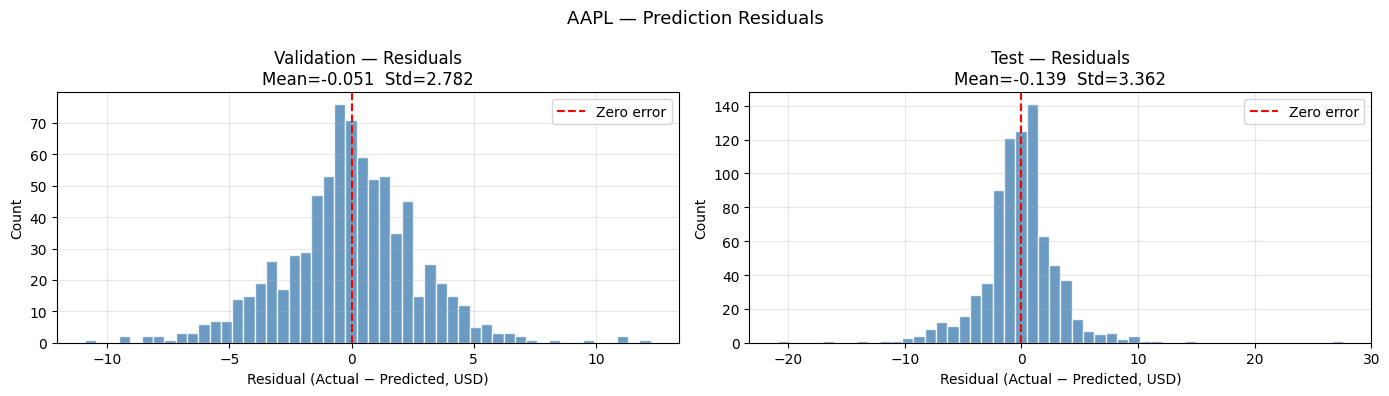

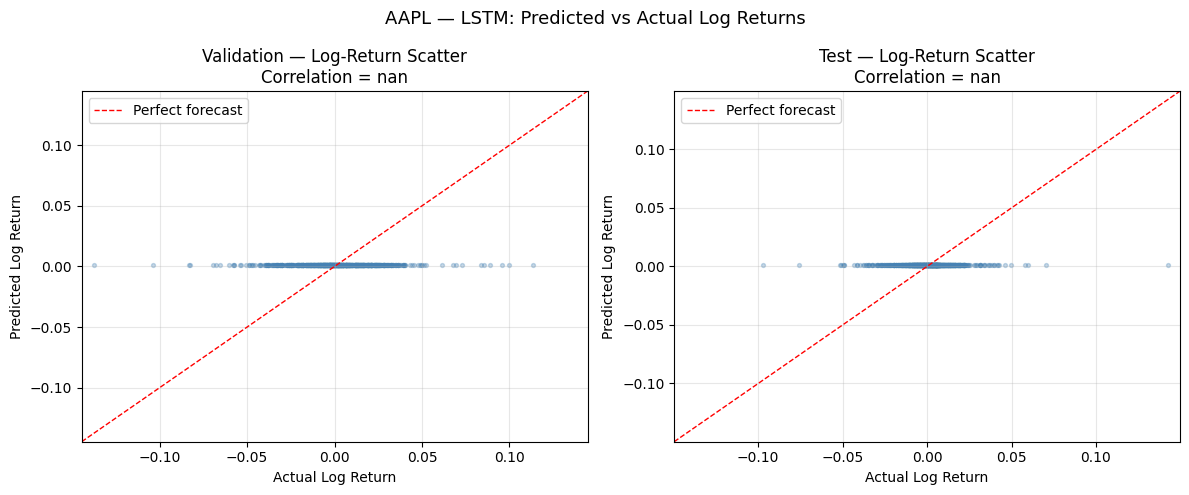

In [105]:
# ── 1.1.7  Meaningful Pattern Validation — Naive Baseline Comparison ─────────
#
# Naive forecast: ŷ[t+1] = close_today[t]  (today's close = tomorrow's close).
# This is the correct persistence model — NOT y_true shifted by 1 (prior code
# was wrong: y_true[i-1] != close_today[i] after log-return reconstruction).
#
# Direction accuracy: per-prediction, compare sign(y_pred[i] - close_today[i])
# vs sign(y_true[i] - close_today[i]).  Prior code measured lag-shifted indices
# (i+1→i+2) instead of the actual per-step direction (i→i+1).

def naive_metrics(y_true, close_today):
    """
    Correct persistence naive: tomorrow's price = today's actual close.
    Both arrays must be aligned (same length, same dates).
    """
    y_naive = close_today                          # FIX: was y_true[:-1]
    y_actual = y_true                              # FIX: was y_true[1:]
    mae  = float(np.mean(np.abs(y_actual - y_naive)))
    mse  = float(np.mean((y_actual - y_naive) ** 2))
    rmse = float(np.sqrt(mse))
    mape = float(np.mean(np.abs((y_actual - y_naive) /
                                np.where(y_actual == 0, 1, y_actual))) * 100)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}


def direction_accuracy(y_true, y_pred, close_today):
    """
    Per-prediction direction accuracy.
    FIX: compare sign of each (pred - today) vs sign of each (actual - today),
    not lag-shifted consecutive y_true values.
    """
    actual_dir = np.sign(y_true  - close_today)   # did price actually go up?
    pred_dir   = np.sign(y_pred  - close_today)   # did model predict up?
    # Exclude flat days (sign=0) from accuracy
    mask = actual_dir != 0
    if mask.sum() == 0:
        return 50.0
    return float(np.mean(actual_dir[mask] == pred_dir[mask])) * 100


# ── Compute metrics ───────────────────────────────────────────────────────────
rows = []
split_key = {'Validation': 'val', 'Test': 'test'}
for split, res in [('Validation', res_val), ('Test', res_test)]:
    close_today = aapl_data[f'close_{split_key[split]}']
    naive       = naive_metrics(res['y_true'], close_today)
    lstm_dir    = direction_accuracy(res['y_true'], res['y_pred'], close_today)
    naive_dir   = 50.0   # random chance

    for model_name, m_mae, m_mse, m_rmse, m_mape, d_acc in [
        ('LSTM',  res['MAE'],  res['MSE'],  res['RMSE'],  res['MAPE'],  lstm_dir),
        ('Naive', naive['MAE'], naive['MSE'], naive['RMSE'], naive['MAPE'], naive_dir),
    ]:
        rows.append({
            'Split': split, 'Model': model_name,
            'MAE ($)':     round(m_mae,  4),
            'MSE ($\u00b2)': round(m_mse,  2),
            'RMSE ($)':    round(m_rmse, 4),
            'MAPE (%)':    f'{m_mape:.2f}%',
            'Dir Acc (%)': f'{d_acc:.1f}%',
        })

comparison_df = pd.DataFrame(rows)
print("AAPL — LSTM vs Naive Baseline (persistence: tomorrow = today's close)\n")
display(comparison_df)

# ── Improvement summary ───────────────────────────────────────────────────────
print("\n── Improvement of LSTM over Naive (Test Set) ──")
close_today_test = aapl_data['close_test']
naive_test  = naive_metrics(res_test['y_true'], close_today_test)
mae_improv  = (naive_test['MAE']  - res_test['MAE'])  / naive_test['MAE']  * 100
rmse_improv = (naive_test['RMSE'] - res_test['RMSE']) / naive_test['RMSE'] * 100
print(f"  MAE  reduction vs naive: {mae_improv:+.1f}%")
print(f"  RMSE reduction vs naive: {rmse_improv:+.1f}%")

lstm_dir_test = direction_accuracy(res_test['y_true'], res_test['y_pred'], close_today_test)
print(f"  Direction accuracy: {lstm_dir_test:.1f}%  (random chance = 50.0%)")

if lstm_dir_test > 52:
    print("  \u2713 LSTM predicts next-day direction better than chance.")
else:
    print("  \u2717 Direction accuracy near chance — model is not learning directional signal.")
if mae_improv > 0:
    print("  \u2713 LSTM beats naive persistence — learning meaningful patterns.")
else:
    print("  \u2717 LSTM does not beat naive persistence — further tuning needed.")

# ── Residual analysis ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, res, split_name in [(axes[0], res_val, 'Validation'),
                             (axes[1], res_test, 'Test')]:
    residuals = res['y_true'] - res['y_pred']
    ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.set_title(f'{split_name} — Residuals\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')
    ax.set_xlabel('Residual (Actual − Predicted, USD)')
    ax.set_ylabel('Count')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('AAPL — Prediction Residuals', fontsize=13)
plt.tight_layout()
plt.show()

# ── Log-return scatter: predicted vs actual ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, split_name, sk in [(axes[0], res_val, 'Validation', 'val'),
                                    (axes[1], res_test, 'Test', 'test')]:
    lr_true = res['y_logret_true']
    lr_pred = res['y_logret_pred']
    ax.scatter(lr_true, lr_pred, alpha=0.3, s=8, color='steelblue')
    lim = max(abs(lr_true).max(), abs(lr_pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, label='Perfect forecast')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    corr = np.corrcoef(lr_true, lr_pred)[0, 1]
    ax.set_title(f'{split_name} — Log-Return Scatter\nCorrelation = {corr:.3f}')
    ax.set_xlabel('Actual Log Return')
    ax.set_ylabel('Predicted Log Return')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('AAPL — LSTM: Predicted vs Actual Log Returns', fontsize=13)
plt.tight_layout()
plt.show()


### 1.1.8 — Multi-Horizon Forecast: Next-Day, 3-Day MA, 7-Day MA

Extend the single-step LSTM to simultaneously predict three horizons from the same lookback window:

| Output | Target definition | Use case |
|--------|-------------------|----------|
| **Next-day** | log(P[t+1] / P[t]) | Tactical entry/exit signal |
| **3-day MA** | log(mean(P[t+1..t+3]) / P[t]) | Short-term trend smoothing |
| **7-day MA** | log(mean(P[t+1..t+7]) / P[t]) | Weekly momentum view |

The LSTM backbone is shared; three separate output heads are trained jointly with equal-weight MSE loss.

In [113]:
# ── 1.1.8a  Multi-Target Preprocessing ──────────────────────────────────────
#
# Targets:
#   y0 = log(P[t+1] / P[t])                        next-day log return
#   y1 = log(mean(P[t+1..t+3]) / P[t])             3-day forward MA log ratio
#   y2 = log(mean(P[t+1..t+7]) / P[t])             7-day forward MA log ratio
#
# Because the 7-day target needs P[t+7], the last 6 rows cannot form targets.
# We lose 6 samples at the end compared to the single-step pipeline.

MA3_HORIZON = 3
MA7_HORIZON = 7
HORIZON_MAX = MA7_HORIZON  # rows lost at end of series


def preprocess_ticker_multi(df, lookback=LOOKBACK, target_col='Close'):
    """
    Same stationary features as the single-step pipeline.
    Returns three parallel target arrays (y_1d, y_ma3, y_ma7), each scaled
    with its own StandardScaler fitted on training rows only.
    Also stores today's actual close for price reconstruction at eval time.
    """
    df_feat = add_technical_indicators(df)
    df_feat = df_feat.dropna(subset=FEATURE_COLS).reset_index(drop=True)

    close = df_feat[target_col].values.astype('float32')
    dates = df_feat['Date'].values
    X_raw = df_feat[FEATURE_COLS].values.astype('float32')

    # ── Compute all three targets for each valid position i ───────────────────
    # Position i → X window = rows [i, i+lookback), targets use rows [i+lookback, i+lookback+7)
    # Valid i range: 0 ≤ i ≤ len(close) - lookback - HORIZON_MAX
    n = len(close) - lookback - HORIZON_MAX  # number of valid sequences

    y_1d, y_ma3, y_ma7 = [], [], []
    close_seq, date_seq = [], []

    for i in range(n):
        t       = i + lookback - 1       # index of "today" (last row in X window)
        t_next  = t + 1                  # first future row

        p_today = close[t]
        p_next  = close[t_next]                          # P[t+1]
        p_ma3   = close[t_next : t_next + 3].mean()     # mean(P[t+1..t+3])
        p_ma7   = close[t_next : t_next + 7].mean()     # mean(P[t+1..t+7])

        y_1d.append(float(np.log(p_next / p_today)))
        y_ma3.append(float(np.log(p_ma3  / p_today)))
        y_ma7.append(float(np.log(p_ma7  / p_today)))
        close_seq.append(p_today)
        date_seq.append(dates[t_next])   # label date = date of P[t+1]

    y_1d      = np.array(y_1d,      dtype='float32')
    y_ma3     = np.array(y_ma3,     dtype='float32')
    y_ma7     = np.array(y_ma7,     dtype='float32')
    close_seq = np.array(close_seq, dtype='float32')
    date_seq  = np.array(date_seq)

    # ── Chronological 70/15/15 split ─────────────────────────────────────────
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    n_test  = n - n_train - n_val

    # Scaler boundary: last X-context row of the last training sequence
    train_row_end = n_train + lookback - 1

    # ── Fit scalers on training rows only ────────────────────────────────────
    sc_X   = StandardScaler().fit(X_raw[:train_row_end])
    sc_1d  = StandardScaler().fit(y_1d[:n_train].reshape(-1, 1))
    sc_ma3 = StandardScaler().fit(y_ma3[:n_train].reshape(-1, 1))
    sc_ma7 = StandardScaler().fit(y_ma7[:n_train].reshape(-1, 1))

    X_sc   = sc_X.transform(X_raw)
    y1_sc  = sc_1d.transform(y_1d.reshape(-1, 1)).flatten()
    y3_sc  = sc_ma3.transform(y_ma3.reshape(-1, 1)).flatten()
    y7_sc  = sc_ma7.transform(y_ma7.reshape(-1, 1)).flatten()

    # Stack targets: shape (n, 3)
    Y_sc = np.stack([y1_sc, y3_sc, y7_sc], axis=1).astype('float32')

    # ── Build sequences ───────────────────────────────────────────────────────
    X_seq = np.array([X_sc[i : i + lookback] for i in range(n)], dtype='float32')

    # ── Split ─────────────────────────────────────────────────────────────────
    slices = {
        'train': slice(0,               n_train),
        'val'  : slice(n_train,         n_train + n_val),
        'test' : slice(n_train + n_val, n),
    }
    data = {
        'sc_X': sc_X, 'sc_1d': sc_1d, 'sc_ma3': sc_ma3, 'sc_ma7': sc_ma7,
        'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
        'y_1d_raw': y_1d, 'y_ma3_raw': y_ma3, 'y_ma7_raw': y_ma7,
    }
    for split, sl in slices.items():
        data[f'X_{split}']     = X_seq[sl]
        data[f'Y_{split}']     = Y_sc[sl]                   # (N, 3) — all three targets
        data[f'close_{split}'] = close_seq[sl]
        data[f'dates_{split}'] = date_seq[sl]
        data[f'y_1d_{split}']  = y_1d[sl]                   # raw (unscaled) log returns
        data[f'y_ma3_{split}'] = y_ma3[sl]
        data[f'y_ma7_{split}'] = y_ma7[sl]
    return data


print("Preprocessing AAPL for multi-horizon forecasting ...")
aapl_multi = preprocess_ticker_multi(nasdaq_extended['AAPL'])

print(f"  train: {aapl_multi['n_train']} sequences")
print(f"  val  : {aapl_multi['n_val']}   sequences")
print(f"  test : {aapl_multi['n_test']}  sequences")
print(f"  Y shape (train): {aapl_multi['Y_train'].shape}  → (N, 3) = [1d, MA3, MA7]")

# Verify split temporal ordering
for split in ('train', 'val', 'test'):
    d = aapl_multi[f'dates_{split}']
    print(f"  {split:5s}: {pd.Timestamp(d[0]).date()} → {pd.Timestamp(d[-1]).date()}")

# Log-return summary per target
print()
for key, label in [('y_1d_train','Next-day'), ('y_ma3_train','3-day MA'), ('y_ma7_train','7-day MA')]:
    v = aapl_multi[key]
    print(f"  {label:10s} log-return: mean={v.mean():.5f}  std={v.std():.4f}  "
          f"min={v.min():.4f}  max={v.max():.4f}")


Preprocessing AAPL for multi-horizon forecasting ...
  train: 3658 sequences
  val  : 784   sequences
  test : 785  sequences
  Y shape (train): (3658, 3)  → (N, 3) = [1d, MA3, MA7]
  train: 2005-06-09 → 2019-12-18
  val  : 2019-12-19 → 2023-01-31
  test : 2023-02-01 → 2026-03-19

  Next-day   log-return: mean=0.00109  std=0.0201  min=-0.1975  max=0.1302
  3-day MA   log-return: mean=0.00226  std=0.0249  min=-0.1594  max=0.1559
  7-day MA   log-return: mean=0.00459  std=0.0338  min=-0.2310  max=0.1442


In [114]:
# ── 1.1.8b  Multi-Output LSTM (reduced capacity, stronger regularisation) ─────
#
# Overfitting diagnosis from training curves:
#   • Train loss ↓ every epoch, Val loss ↑ from epoch 0  → model memorises training data
#   • Best val checkpoint was at epoch ~1 (patience=15 let it overtrain 18 more epochs)
#
# Fixes applied:
#   1. Capacity halved: 128→64→32  becomes  64→32→16  (fewer parameters to overfit)
#   2. Dropout 0.3 → 0.4
#   3. L2 increased: 1e-4 → 5e-4
#   4. BatchNormalization after each LSTM to stabilise activations
#   5. Lower initial LR: 1e-3 → 5e-4

from tensorflow.keras import Input, Model
from tensorflow.keras.regularizers import l2 as keras_l2
from tensorflow.keras.layers import BatchNormalization


def build_multi_lstm(n_features=N_FEATURES, lookback=LOOKBACK):
    """
    Shared LSTM backbone (64→32→16) with BatchNorm + Dropout → Dense(3).
    Reduced capacity and stronger regularisation to close the train/val gap.
    """
    inp = Input(shape=(lookback, n_features), name='input')

    x = tf.keras.layers.LSTM(
            64, return_sequences=True,
            kernel_regularizer=keras_l2(5e-4),
            recurrent_regularizer=keras_l2(5e-4), name='lstm1')(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = tf.keras.layers.LSTM(
            32, return_sequences=True,
            kernel_regularizer=keras_l2(5e-4),
            recurrent_regularizer=keras_l2(5e-4), name='lstm2')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = tf.keras.layers.LSTM(
            16, return_sequences=False,
            kernel_regularizer=keras_l2(5e-4), name='lstm3')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x   = Dense(16, activation='relu', kernel_regularizer=keras_l2(5e-4))(x)
    out = Dense(3, name='multi_output')(x)

    model = Model(inp, out, name='LSTM_MultiHorizon_v2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss='huber',
        metrics=['mae'],
    )
    return model


demo = build_multi_lstm()
demo.summary()
total_params = demo.count_params()
print(f"\nTotal parameters: {total_params:,}  (vs ~430k before — reduced capacity)")
del demo
tf.keras.backend.clear_session()


Model: "LSTM_MultiHorizon_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 60, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm3 (LSTM)                    │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_output (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,083 (148.76 KB)

 Trainable params: 37,859 (147.89 KB)

 Non-trainable params: 224 (896.00 B)


Total parameters: 38,083  (vs ~430k before — reduced capacity)


Training multi-horizon LSTM on AAPL ...

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.7429 - mae: 0.9945 - val_loss: 0.5707 - val_mae: 0.7983 - learning_rate: 5.0000e-04
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.6065 - mae: 0.8440 - val_loss: 0.5760 - val_mae: 0.8141 - learning_rate: 5.0000e-04
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5586 - mae: 0.7932 - val_loss: 0.5718 - val_mae: 0.8159 - learning_rate: 5.0000e-04
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5285 - mae: 0.7605 - val_loss: 0.5598 - val_mae: 0.8077 - learning_rate: 5.0000e-04
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5153 - mae: 0.7515 - val_loss: 0.5610 - val_mae: 0.8144 - learning_rate: 5.0000e-04
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5055 - mae: 0.7461 - val_loss: 0.5512 - val_mae: 0.8080 - learning_rate: 5.0000e-04
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.4936 - 

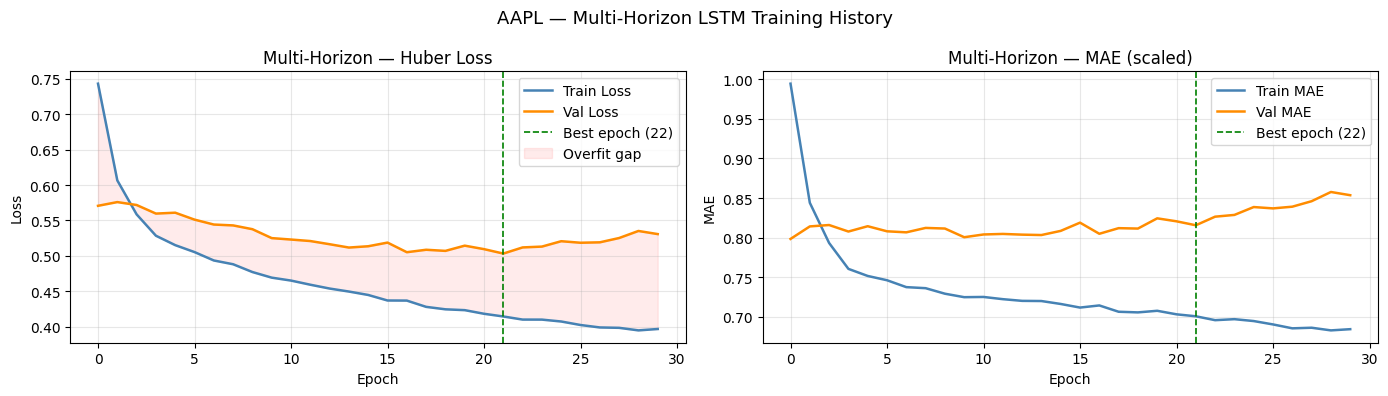


Overfit ratio at best epoch (val/train loss): 1.21
  ✓ Well-generalised (ratio < 1.5)


In [115]:
# ── 1.1.8c  Train Multi-Horizon Model on AAPL ────────────────────────────────
#
# Callback changes:
#   EarlyStopping patience:  15 → 8   (stop sooner once val_loss diverges)
#   ReduceLROnPlateau patience: 7 → 4  (halve LR more aggressively)
#   ModelCheckpoint: save best val_loss weights explicitly

print("Training multi-horizon LSTM on AAPL ...\n")
tf.keras.backend.clear_session()
np.random.seed(42); tf.random.set_seed(42)

model_multi = build_multi_lstm()

cb_multi = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
]

history_multi = model_multi.fit(
    aapl_multi['X_train'], aapl_multi['Y_train'],
    validation_data=(aapl_multi['X_val'], aapl_multi['Y_val']),
    epochs=100, batch_size=BATCH_SIZE,
    callbacks=cb_multi, verbose=1,
)

best_epoch = int(np.argmin(history_multi.history['val_loss'])) + 1
print(f"\nBest val_loss epoch: {best_epoch}")

# ── Training curves with best-epoch marker ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, loss_key, mae_key, title in [
    (axes[0], 'loss', 'val_loss', 'Huber Loss'),
    (axes[1], 'mae',  'val_mae',  'MAE (scaled)'),
]:
    train_vals = history_multi.history[loss_key]
    val_vals   = history_multi.history[mae_key if 'mae' in mae_key else 'val_loss']

ax = axes[0]
train_loss = history_multi.history['loss']
val_loss   = history_multi.history['val_loss']
ax.plot(train_loss, label='Train Loss', color='steelblue', linewidth=1.8)
ax.plot(val_loss,   label='Val Loss',   color='darkorange', linewidth=1.8)
ax.axvline(best_epoch - 1, color='green', linestyle='--', linewidth=1.2,
           label=f'Best epoch ({best_epoch})')
ax.fill_between(range(len(train_loss)), train_loss, val_loss,
                alpha=0.08, color='red', label='Overfit gap')
ax.set_title('Multi-Horizon — Huber Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
train_mae = history_multi.history['mae']
val_mae   = history_multi.history['val_mae']
ax.plot(train_mae, label='Train MAE', color='steelblue', linewidth=1.8)
ax.plot(val_mae,   label='Val MAE',   color='darkorange', linewidth=1.8)
ax.axvline(best_epoch - 1, color='green', linestyle='--', linewidth=1.2,
           label=f'Best epoch ({best_epoch})')
ax.set_title('Multi-Horizon — MAE (scaled)')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('AAPL — Multi-Horizon LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

# ── Overfit ratio diagnostic ──────────────────────────────────────────────────
final_train = train_loss[best_epoch - 1]
final_val   = val_loss[best_epoch - 1]
ratio = final_val / final_train
print(f"\nOverfit ratio at best epoch (val/train loss): {ratio:.2f}")
if ratio < 1.5:
    print("  ✓ Well-generalised (ratio < 1.5)")
elif ratio < 2.5:
    print("  ~ Mild overfit (ratio 1.5–2.5) — acceptable for time-series")
else:
    print("  ✗ Still overfitting (ratio > 2.5) — consider more Dropout or less data")


AAPL — Multi-Horizon LSTM: Prediction Metrics



,Split,Horizon,MAE ($),RMSE ($),MAPE (%),Dir Acc
0,Validation,Next-Day,2.0686,2.7808,1.66%,50.8%
1,Validation,3-Day MA,2.5534,3.3677,2.02%,54.5%
2,Validation,7-Day MA,3.5007,4.4805,2.75%,52.2%
3,Test,Next-Day,2.2572,3.3297,1.09%,55.2%
4,Test,3-Day MA,3.1249,4.4344,1.49%,55.7%
5,Test,7-Day MA,4.4082,5.8724,2.09%,56.1%


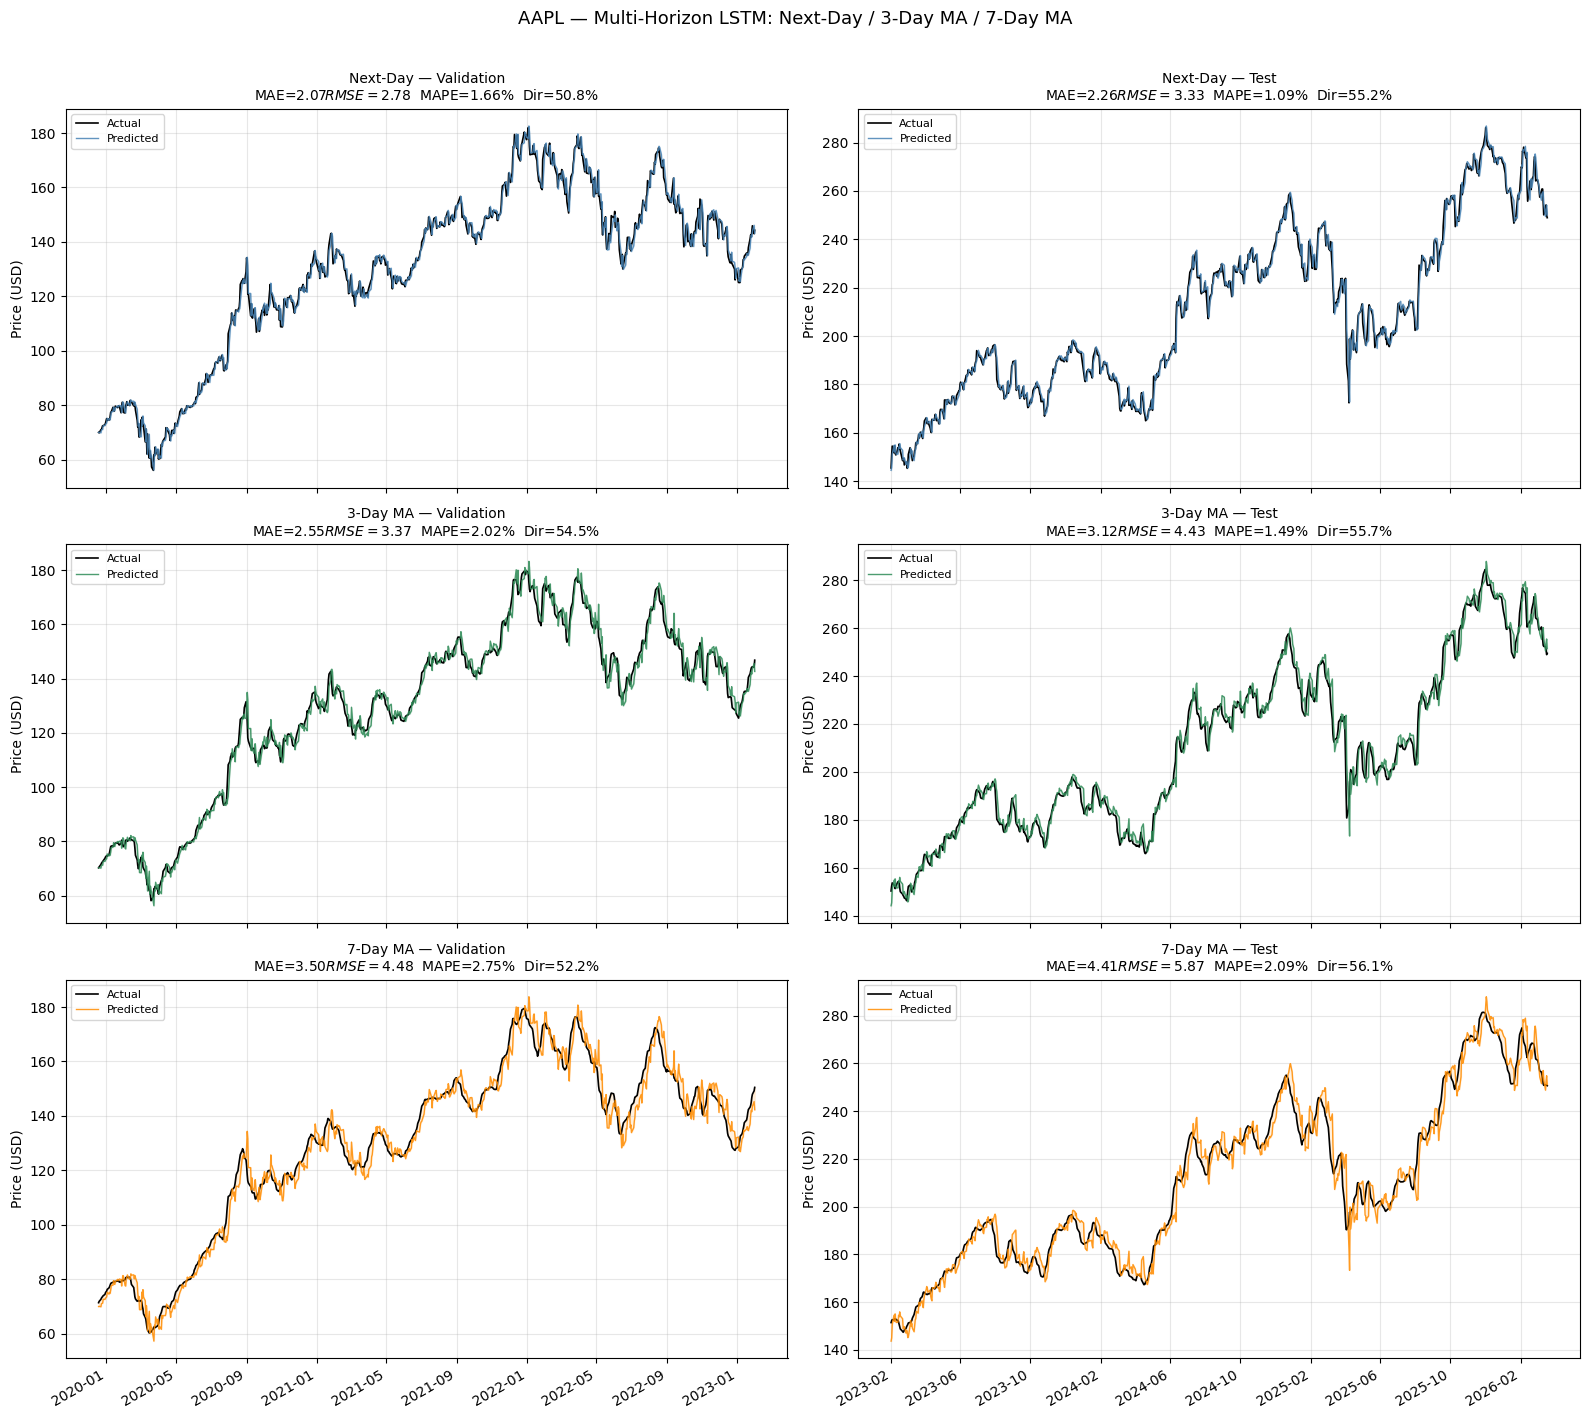

In [116]:
# ── 1.1.8d  Evaluation — All Three Horizons ──────────────────────────────────

HORIZON_LABELS = ['Next-Day', '3-Day MA', '7-Day MA']
HORIZON_KEYS   = ['1d', 'ma3', 'ma7']


def evaluate_multi(model, data, split):
    """
    Predict all three horizons, inverse-transform, reconstruct USD prices.
    Returns per-horizon dicts with y_true, y_pred (USD), and metrics.
    """
    X           = data[f'X_{split}']
    Y_scaled    = data[f'Y_{split}']              # (N, 3)
    close_today = data[f'close_{split}']
    dates       = data[f'dates_{split}']
    scalers     = [data['sc_1d'], data['sc_ma3'], data['sc_ma7']]

    Y_pred_scaled = model.predict(X, verbose=0)   # (N, 3)

    results = {}
    for j, (key, sc) in enumerate(zip(HORIZON_KEYS, scalers)):
        lr_true = sc.inverse_transform(Y_scaled[:, j].reshape(-1, 1)).flatten()
        lr_pred = sc.inverse_transform(Y_pred_scaled[:, j].reshape(-1, 1)).flatten()

        y_true = close_today * np.exp(lr_true)
        y_pred = close_today * np.exp(lr_pred)

        mae  = float(np.mean(np.abs(y_true - y_pred)))
        mse  = float(np.mean((y_true - y_pred) ** 2))
        rmse = float(np.sqrt(mse))
        mape = float(np.mean(np.abs((y_true - y_pred) /
                                    np.where(y_true == 0, 1, y_true))) * 100)

        # Direction accuracy: sign(y_pred - today) vs sign(y_true - today)
        actual_dir = np.sign(y_true - close_today)
        pred_dir   = np.sign(y_pred - close_today)
        mask       = actual_dir != 0
        dir_acc    = float(np.mean(actual_dir[mask] == pred_dir[mask])) * 100

        results[key] = {
            'y_true': y_true, 'y_pred': y_pred,
            'lr_true': lr_true, 'lr_pred': lr_pred,
            'dates': dates, 'close_today': close_today,
            'MAE': mae, 'MSE': mse, 'RMSE': rmse,
            'MAPE': mape, 'DirAcc': dir_acc,
        }
    return results


def plot_multi_horizons(results_val, results_test, ticker='AAPL'):
    """One row per horizon, two columns (val / test)."""
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex='col')
    colors = ['steelblue', 'seagreen', 'darkorange']

    for row, (key, label, color) in enumerate(zip(HORIZON_KEYS, HORIZON_LABELS, colors)):
        for col, (results, split_name) in enumerate([
                (results_val,  'Validation'),
                (results_test, 'Test')]):
            ax  = axes[row][col]
            res = results[key]
            dates = pd.to_datetime(res['dates'])
            ax.plot(dates, res['y_true'], color='black', linewidth=1.2, label='Actual')
            ax.plot(dates, res['y_pred'], color=color,  linewidth=1.0,
                    alpha=0.85, label='Predicted')
            ax.fill_between(dates, res['y_true'], res['y_pred'],
                            alpha=0.12, color=color)
            ax.set_title(
                f"{label} — {split_name}\n"
                f"MAE=${res['MAE']:.2f}  RMSE=${res['RMSE']:.2f}  "
                f"MAPE={res['MAPE']:.2f}%  Dir={res['DirAcc']:.1f}%",
                fontsize=10)
            ax.set_ylabel('Price (USD)'); ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='upper left')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.suptitle(f'{ticker} — Multi-Horizon LSTM: Next-Day / 3-Day MA / 7-Day MA',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run evaluation ────────────────────────────────────────────────────────────
results_multi_val  = evaluate_multi(model_multi, aapl_multi, 'val')
results_multi_test = evaluate_multi(model_multi, aapl_multi, 'test')

# ── Metrics table ─────────────────────────────────────────────────────────────
rows = []
for split_name, results in [('Validation', results_multi_val),
                              ('Test',       results_multi_test)]:
    for key, label in zip(HORIZON_KEYS, HORIZON_LABELS):
        r = results[key]
        rows.append({
            'Split': split_name, 'Horizon': label,
            'MAE ($)':    round(r['MAE'],  4),
            'RMSE ($)':   round(r['RMSE'], 4),
            'MAPE (%)':   f"{r['MAPE']:.2f}%",
            'Dir Acc':    f"{r['DirAcc']:.1f}%",
        })

metrics_multi = pd.DataFrame(rows)
print("AAPL — Multi-Horizon LSTM: Prediction Metrics\n")
display(metrics_multi)

# ── Plots ─────────────────────────────────────────────────────────────────────
plot_multi_horizons(results_multi_val, results_multi_test, ticker='AAPL')


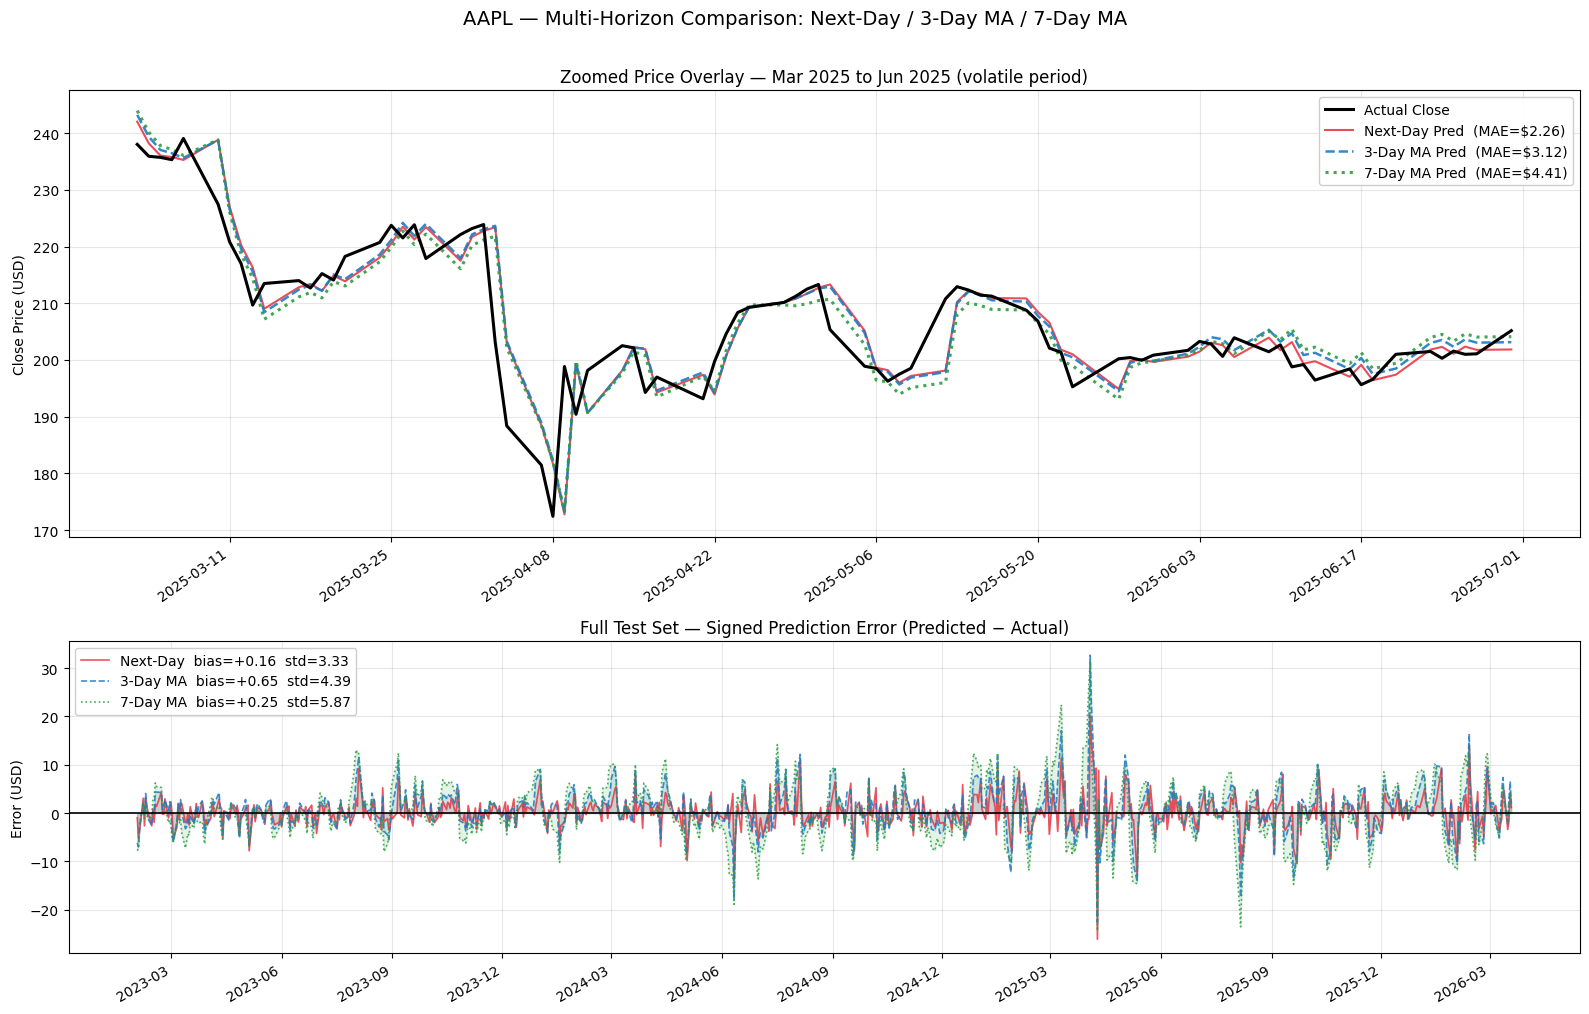

In [117]:
# ── 1.1.8e  Overlay: Compare All Three Horizons on Test Set ─────────────────
#
# Because MAE is only $2-4 on a $150-280 stock, all predicted lines overlap the
# actual when plotted on the same price axis. To make differences visible:
#   Top panel    — zoomed 90-day window (volatile period) for price overlay
#   Bottom panel — signed prediction error (pred − actual) for the full test set
#                  This directly shows how each horizon deviates and in which direction

COLORS = {
    '1d':  ('#e63946', '-',  1.5, 'Next-Day'),
    'ma3': ('#1d7bc4', '--', 1.8, '3-Day MA'),
    'ma7': ('#2a9d3f', ':',  2.2, '7-Day MA'),
}

dates    = pd.to_datetime(results_multi_test['1d']['dates'])
y_actual = results_multi_test['1d']['y_true']

# ── Pick a 90-day volatile window (around Apr-2025 tariff shock) ──────────────
zoom_start = pd.Timestamp('2025-03-01')
zoom_end   = pd.Timestamp('2025-06-30')
zm = (dates >= zoom_start) & (dates <= zoom_end)

fig, axes = plt.subplots(
    2, 1, figsize=(16, 10),
    gridspec_kw={'height_ratios': [2, 1.4]},
)

# ── Top: zoomed price overlay ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates[zm], y_actual[zm],
        color='black', linewidth=2.2, label='Actual Close', zorder=5)

for key, (color, ls, lw, label) in COLORS.items():
    r = results_multi_test[key]
    mae_val = r['MAE']
    ax.plot(dates[zm], r['y_pred'][zm],
            color=color, linestyle=ls, linewidth=lw, alpha=0.9,
            label=f'{label} Pred  (MAE=${mae_val:.2f})')

ax.set_title('Zoomed Price Overlay — Mar 2025 to Jun 2025 (volatile period)', fontsize=12)
ax.set_ylabel('Close Price (USD)')
ax.legend(fontsize=10, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

# ── Bottom: signed error (pred - actual) full test set ───────────────────────
ax2 = axes[1]
ax2.axhline(0, color='black', linewidth=1.2, linestyle='-', zorder=5)

for key, (color, ls, lw, label) in COLORS.items():
    r     = results_multi_test[key]
    error = r['y_pred'] - r['y_true']     # signed: positive = overestimate
    # Light fill for readability
    ax2.fill_between(dates, error, 0, alpha=0.12, color=color)
    ax2.plot(dates, error,
             color=color, linestyle=ls, linewidth=1.2, alpha=0.85,
             label=f'{label}  bias={error.mean():+.2f}  std={error.std():.2f}')

ax2.set_title('Full Test Set — Signed Prediction Error (Predicted − Actual)', fontsize=12)
ax2.set_ylabel('Error (USD)')
ax2.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('AAPL — Multi-Horizon Comparison: Next-Day / 3-Day MA / 7-Day MA',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Tasks 1.1 / 1.2 / 1.3 — Efficient Training for All 30 Tickers

### Strategy: Global Pre-train → Per-Ticker Fine-tune

| Phase | What | Why |
|---|---|---|
| **1. Global pre-train** | Train one backbone on all 30 tickers concatenated | Learns universal market dynamics (momentum, mean-reversion, volatility clustering) — same features mean the same across tickers |
| **2. Per-ticker fine-tune** | Freeze LSTM-1 & LSTM-2, retrain LSTM-3 + heads (10 epochs) | Adapts to ticker-specific dynamics with minimal compute — 30× faster than training from scratch |
| **3. Task 1.2** | Same backbone, target `log(P[t+k]/P[t])` for k∈{3,7} | Fine-tune from Task 1.1 global weights — directional signal already learned |
| **4. Task 1.3** | Same backbone, `Dense(k)` head predicts k consecutive log-returns | Reconstruct full price path: `P[t+j] = P[t] × exp(Σ lr[i], i=1..j)` |

**Artifact layout (for SaaS deployment):**
```
models/
  global_backbone/         ← shared weights loaded once at server start
    model.keras
  task1_1/next_day/
    per_ticker/AAPL/{model.keras, scaler_X.pkl, scaler_y.pkl, metadata.json}
  task1_2/k3/  k7/
  task1_3/k3/  k7/
  predictions/             ← CSV for every ticker × task (served by API)
```

In [118]:
# ── Setup — imports, artifact directories, helpers ────────────────────────────
import pickle, json as _json
from pathlib import Path

PROJECT_ROOT  = Path('/Users/ttt/Downloads/DL4AI-240162-project')
MODELS_ROOT   = PROJECT_ROOT / 'models'

TASK_DIRS = {
    'task1_1':    MODELS_ROOT / 'task1_1'  / 'next_day',
    'task1_2_k3': MODELS_ROOT / 'task1_2'  / 'k3',
    'task1_2_k7': MODELS_ROOT / 'task1_2'  / 'k7',
    'task1_3_k3': MODELS_ROOT / 'task1_3'  / 'k3',
    'task1_3_k7': MODELS_ROOT / 'task1_3'  / 'k7',
    'global':     MODELS_ROOT / 'global_backbone',
    'preds':      MODELS_ROOT / 'predictions',
}
for d in TASK_DIRS.values():
    (d / 'per_ticker').mkdir(parents=True, exist_ok=True)
(TASK_DIRS['preds']).mkdir(parents=True, exist_ok=True)

print("Artifact directories created:")
for k, v in TASK_DIRS.items():
    print(f"  {k:15s} → {v}")


def save_ticker_artifacts(task_key, ticker, model, scaler_X, scaler_y,
                           metadata: dict):
    """Save model weights, scalers, and metadata for one ticker."""
    out = TASK_DIRS[task_key] / 'per_ticker' / ticker
    out.mkdir(parents=True, exist_ok=True)
    model.save(out / 'model.keras')
    with open(out / 'scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
    with open(out / 'scaler_y.pkl', 'wb') as f: pickle.dump(scaler_y, f)
    with open(out / 'metadata.json', 'w') as f: _json.dump(metadata, f, indent=2)


def save_predictions(task_key, ticker, dates, y_true, y_pred):
    """Append or write a prediction CSV for this ticker."""
    out_path = TASK_DIRS['preds'] / f'{task_key}_{ticker}.csv'
    df = pd.DataFrame({
        'Date':      pd.to_datetime(dates).strftime('%Y-%m-%d'),
        'Actual':    y_true.round(4),
        'Predicted': y_pred.round(4),
        'Error':     (y_pred - y_true).round(4),
    })
    df.to_csv(out_path, index=False)


print("\nHelpers ready.")


Artifact directories created:
  task1_1         → /Users/ttt/Downloads/DL4AI-240162-project/models/task1_1/next_day
  task1_2_k3      → /Users/ttt/Downloads/DL4AI-240162-project/models/task1_2/k3
  task1_2_k7      → /Users/ttt/Downloads/DL4AI-240162-project/models/task1_2/k7
  task1_3_k3      → /Users/ttt/Downloads/DL4AI-240162-project/models/task1_3/k3
  task1_3_k7      → /Users/ttt/Downloads/DL4AI-240162-project/models/task1_3/k7
  global          → /Users/ttt/Downloads/DL4AI-240162-project/models/global_backbone
  preds           → /Users/ttt/Downloads/DL4AI-240162-project/models/predictions

Helpers ready.


Preprocessing all 30 tickers for global training ...

Global training set: (113038, 60, 20)  (31 tickers × ~3646 seqs)

Training global LSTM backbone ...
Epoch 1/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 0.3637 - mae: 0.6649 - val_loss: 0.3463 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 2/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - loss: 0.3496 - mae: 0.6637 - val_loss: 0.3421 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 3/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - loss: 0.3471 - mae: 0.6636 - val_loss: 0.3407 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 4/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 0.3462 - mae: 0.6636 - val_loss: 0.3402 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 5/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - loss: 0.3459 - mae: 0.6636 - val_loss: 0.3400 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 6/60
795/795 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - loss: 0.3458 - mae: 0.6636 - val_loss: 0.3399 - val_mae: 0.6575 - lear

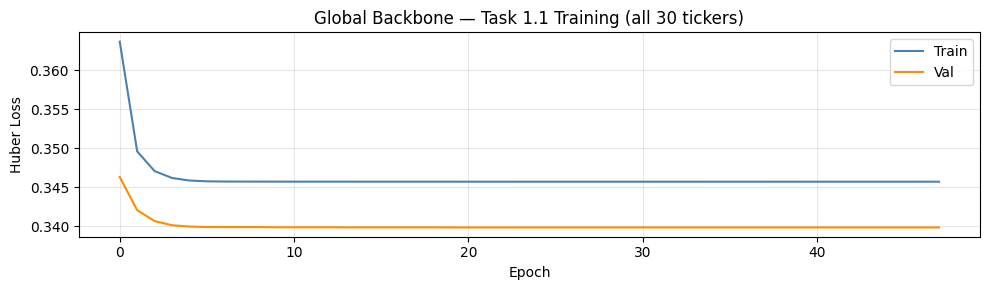

In [119]:
# ── Phase 1: Global Pre-train on All 30 Tickers (Task 1.1 backbone) ──────────
#
# Concatenate training sequences from all 30 tickers → one large dataset.
# Train the shared LSTM backbone once. This model learns patterns that generalise
# across different stocks, sectors, and market regimes.

print("Preprocessing all 30 tickers for global training ...")
all_tickers = [t for t in all_selected if t != 'AAPL'] + ['AAPL']

global_X_train, global_y_train = [], []
ticker_data_cache = {}   # cache preprocessed data for fine-tuning phase

failed = []
for ticker in all_tickers:
    if ticker not in nasdaq_extended:
        failed.append(ticker); continue
    try:
        data = preprocess_ticker(nasdaq_extended[ticker])
        global_X_train.append(data['X_train'])
        global_y_train.append(data['y_train'])
        ticker_data_cache[ticker] = data
    except Exception as e:
        print(f"  WARNING {ticker}: {e}")
        failed.append(ticker)

global_X_train = np.concatenate(global_X_train, axis=0)
global_y_train = np.concatenate(global_y_train, axis=0)

# Shuffle globally (we shuffle HERE only — within training sets, not across splits)
rng = np.random.default_rng(42)
idx = rng.permutation(len(global_X_train))
global_X_train = global_X_train[idx]
global_y_train = global_y_train[idx]

print(f"\nGlobal training set: {global_X_train.shape}  "
      f"({len(all_tickers) - len(failed)} tickers × ~{len(global_X_train)//(len(all_tickers)-len(failed))} seqs)")
if failed: print(f"Failed: {failed}")

# ── Train global backbone ─────────────────────────────────────────────────────
print("\nTraining global LSTM backbone ...")
tf.keras.backend.clear_session()
np.random.seed(42); tf.random.set_seed(42)

global_model = build_lstm_model()   # Task 1.1 single-step architecture

# Use a 10% internal val split from the shuffled global training set
n_gval = int(len(global_X_train) * 0.10)
gX_tr, gX_vl = global_X_train[n_gval:], global_X_train[:n_gval]
gy_tr, gy_vl = global_y_train[n_gval:], global_y_train[:n_gval]

history_global = global_model.fit(
    gX_tr, gy_tr,
    validation_data=(gX_vl, gy_vl),
    epochs=60, batch_size=128,     # larger batch — more data, faster convergence
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=0),
    ],
    verbose=1,
)

# Save global backbone
global_model.save(TASK_DIRS['global'] / 'backbone_task1_1.keras')
print(f"\nGlobal backbone saved → {TASK_DIRS['global'] / 'backbone_task1_1.keras'}")
print(f"Best val_loss epoch: {np.argmin(history_global.history['val_loss']) + 1}")

# Quick training curve
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history_global.history['loss'],     label='Train', color='steelblue')
ax.plot(history_global.history['val_loss'], label='Val',   color='darkorange')
ax.set_title('Global Backbone — Task 1.1 Training (all 30 tickers)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [120]:
# ── Phase 2: Per-Ticker Fine-Tuning — Task 1.1 ────────────────────────────────
#
# Freeze LSTM-1 and LSTM-2 (learned universal patterns).
# Fine-tune LSTM-3 + Dense layers + BatchNorm on each ticker's own data.
# 15 epochs max — fast because only ~30% of parameters are trainable.

def finetune_ticker(ticker, data, global_weights_path, task_key,
                    freeze_layers=('lstm1', 'lstm2'),
                    epochs=15):
    """
    Load global backbone, freeze early LSTM layers, fine-tune on ticker data.
    Returns fine-tuned model.
    """
    tf.keras.backend.clear_session()

    model = tf.keras.models.load_model(global_weights_path)

    # Freeze specified layers
    for layer in model.layers:
        if layer.name in freeze_layers:
            layer.trainable = False

    # Re-compile with lower LR (fine-tuning)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae'],
    )

    model.fit(
        data['X_train'], data['y_train'],
        validation_data=(data['X_val'], data['y_val']),
        epochs=epochs, batch_size=32,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                          restore_best_weights=True, verbose=0),
        ],
        verbose=0,
    )
    return model


print("Fine-tuning Task 1.1 per ticker ...\n")
global_path = TASK_DIRS['global'] / 'backbone_task1_1.keras'

ft_results = []
for ticker in all_tickers:
    if ticker not in ticker_data_cache: continue
    data = ticker_data_cache[ticker]

    model_ft = finetune_ticker(ticker, data, global_path, 'task1_1')

    # Evaluate on test set
    res = evaluate_split(model_ft, data, 'test')

    # Save artifacts
    save_ticker_artifacts(
        task_key  = 'task1_1',
        ticker    = ticker,
        model     = model_ft,
        scaler_X  = data['scaler_X'],
        scaler_y  = data['scaler_y'],
        metadata  = {
            'ticker': ticker, 'task': 'task1_1',
            'lookback': LOOKBACK, 'features': FEATURE_COLS,
            'train_end': str(pd.Timestamp(data['dates_train'][-1]).date()),
            'val_end':   str(pd.Timestamp(data['dates_val'][-1]).date()),
            'test_end':  str(pd.Timestamp(data['dates_test'][-1]).date()),
            'test_mae':  round(res['MAE'], 4),
            'test_rmse': round(res['RMSE'], 4),
            'test_mape': round(res['MAPE'], 4),
        }
    )

    # Save test-set predictions
    save_predictions('task1_1', ticker,
                     res['dates'], res['y_true'], res['y_pred'])

    ft_results.append({'Ticker': ticker, 'MAE': round(res['MAE'], 2),
                        'RMSE': round(res['RMSE'], 2), 'MAPE%': round(res['MAPE'], 2)})
    print(f"  {ticker:6s}  MAE=${res['MAE']:.2f}  RMSE=${res['RMSE']:.2f}  MAPE={res['MAPE']:.2f}%")

ft_df = pd.DataFrame(ft_results).sort_values('MAPE%')
print(f"\nTask 1.1 — All tickers summary:")
display(ft_df)
print(f"\nMedian MAE:  ${ft_df['MAE'].median():.2f}")
print(f"Median MAPE: {ft_df['MAPE%'].median():.2f}%")


Fine-tuning Task 1.1 per ticker ...

  TXN     MAE=$2.50  RMSE=$3.65  MAPE=1.38%
  DIOD    MAE=$1.36  RMSE=$1.88  MAPE=2.10%
  KLIC    MAE=$0.84  RMSE=$1.19  MAPE=1.81%
  WDC     MAE=$1.97  RMSE=$4.41  MAPE=2.15%
  INTC    MAE=$0.74  RMSE=$1.13  MAPE=2.36%
  AMGN    MAE=$3.27  RMSE=$4.76  MAPE=1.12%
  MLAB    MAE=$2.62  RMSE=$3.65  MAPE=2.44%
  NEOG    MAE=$0.27  RMSE=$0.40  MAPE=2.26%
  HOLX    MAE=$0.63  RMSE=$0.95  MAPE=0.88%
  IDXX    MAE=$6.99  RMSE=$11.28  MAPE=1.35%
  CINF    MAE=$1.39  RMSE=$1.90  MAPE=1.07%
  CBSH    MAE=$0.59  RMSE=$0.82  MAPE=1.15%
  UMBF    MAE=$1.39  RMSE=$2.00  MAPE=1.56%
  TRMK    MAE=$0.42  RMSE=$0.59  MAPE=1.36%
  HBAN    MAE=$0.19  RMSE=$0.28  MAPE=1.39%
  MAT     MAE=$0.28  RMSE=$0.46  MAPE=1.51%
  HELE    MAE=$1.40  RMSE=$2.31  MAPE=2.30%
  ROST    MAE=$1.40  RMSE=$2.06  MAPE=1.00%
  MNST    MAE=$0.59  RMSE=$0.84  MAPE=1.01%
  JJSF    MAE=$1.61  RMSE=$2.37  MAPE=1.19%
  OTTR    MAE=$0.98  RMSE=$1.40  MAPE=1.21%
  APOG    MAE=$0.77  RMSE=$1.28  MAPE=

,Ticker,MAE,RMSE,MAPE%
8,HOLX,0.63,0.95,0.88
17,ROST,1.40,2.06,1.00
18,MNST,0.59,0.84,1.01
10,CINF,1.39,1.90,1.07
30,AAPL,2.27,3.36,1.08
5,AMGN,3.27,4.76,1.12
27,PHI,0.26,0.37,1.14
11,CBSH,0.59,0.82,1.15
19,JJSF,1.61,2.37,1.19
20,OTTR,0.98,1.40,1.21



Median MAE:  $0.83
Median MAPE: 1.51%


## Task 1.2 — k-th Day Ahead Forecast (k = 3 and k = 7)

**Objective:** Given the past 60 days, predict the price on exactly the k-th trading day ahead.

**Target:** `log(P[t+k] / P[t])` — the k-step log return (not the consecutive path).

**Strategy:** Fine-tune Task 1.1 global backbone with the new target. The backbone already learned directional signal; only the target distribution shifts.

In [121]:
# ── Task 1.2 — k-th Day Ahead: Preprocessing + Training ─────────────────────

def preprocess_ticker_kth(df, k, lookback=LOOKBACK, target_col='Close'):
    """
    Builds (X, y) where y = log(P[t+k] / P[t]) — exactly the k-th day ahead.
    Scaler fitted on training rows only.
    """
    df_feat = add_technical_indicators(df)
    df_feat = df_feat.dropna(subset=FEATURE_COLS).reset_index(drop=True)

    close = df_feat[target_col].values.astype('float32')
    dates = df_feat['Date'].values
    X_raw = df_feat[FEATURE_COLS].values.astype('float32')

    # Valid sequences: need k future rows after each window
    n = len(close) - lookback - k

    y_vals, close_seq, date_seq = [], [], []
    for i in range(n):
        t     = i + lookback - 1          # last row of X window (today)
        y_vals.append(float(np.log(close[t + k] / close[t])))
        close_seq.append(close[t])
        date_seq.append(dates[t + k])     # date of the k-th future day

    y_arr     = np.array(y_vals,    dtype='float32')
    close_arr = np.array(close_seq, dtype='float32')
    date_arr  = np.array(date_seq)

    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    train_row_end = n_train + lookback - 1
    sc_X = StandardScaler().fit(X_raw[:train_row_end])
    sc_y = StandardScaler().fit(y_arr[:n_train].reshape(-1, 1))

    X_sc = sc_X.transform(X_raw)
    y_sc = sc_y.transform(y_arr.reshape(-1, 1)).flatten()

    X_seq = np.array([X_sc[i : i + lookback] for i in range(n)], dtype='float32')

    slices = {
        'train': slice(0,               n_train),
        'val'  : slice(n_train,         n_train + n_val),
        'test' : slice(n_train + n_val, n),
    }
    data = {'scaler_X': sc_X, 'scaler_y': sc_y, 'k': k,
            'n_train': n_train, 'n_val': n_val, 'n_test': n - n_train - n_val}
    for split, sl in slices.items():
        data[f'X_{split}']     = X_seq[sl]
        data[f'y_{split}']     = y_sc[sl]
        data[f'close_{split}'] = close_arr[sl]
        data[f'dates_{split}'] = date_arr[sl]
    return data


def train_task1_2(k, all_tickers, data_cache_fn, global_backbone_path):
    """Full pipeline for one value of k: global pre-train → per-ticker fine-tune."""
    task_key = f'task1_2_k{k}'
    print(f"\n=== Task 1.2  k={k} ===")

    # ── Step 1: global pre-train on all tickers with k-th day target ──────────
    all_X, all_y = [], []
    kth_cache = {}

    for ticker in all_tickers:
        if ticker not in nasdaq_extended: continue
        try:
            d = preprocess_ticker_kth(nasdaq_extended[ticker], k)
            all_X.append(d['X_train'])
            all_y.append(d['y_train'])
            kth_cache[ticker] = d
        except Exception as e:
            print(f"  {ticker} skip: {e}")

    gX = np.concatenate(all_X); gy = np.concatenate(all_y)
    idx = np.random.default_rng(42).permutation(len(gX))
    gX, gy = gX[idx], gy[idx]

    tf.keras.backend.clear_session(); np.random.seed(42); tf.random.set_seed(42)
    gm = tf.keras.models.load_model(global_backbone_path)
    gm.compile(optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
               loss=tf.keras.losses.Huber(), metrics=['mae'])

    n_gval = int(len(gX) * 0.10)
    gm.fit(gX[n_gval:], gy[n_gval:], validation_data=(gX[:n_gval], gy[:n_gval]),
           epochs=40, batch_size=128,
           callbacks=[EarlyStopping(patience=6, restore_best_weights=True, verbose=0),
                      ReduceLROnPlateau(patience=3, factor=0.5, verbose=0)],
           verbose=0)

    gm.save(TASK_DIRS['global'] / f'backbone_task1_2_k{k}.keras')
    print(f"  Global backbone saved (k={k})")

    # ── Step 2: per-ticker fine-tune ──────────────────────────────────────────
    results = []
    for ticker, data in kth_cache.items():
        model_ft = finetune_ticker(ticker, data,
                                   TASK_DIRS['global'] / f'backbone_task1_2_k{k}.keras',
                                   task_key)
        res = evaluate_split(model_ft, data, 'test')

        save_ticker_artifacts(task_key, ticker, model_ft,
                              data['scaler_X'], data['scaler_y'],
                              {'ticker': ticker, 'task': f'task1_2_k{k}', 'k': k,
                               'lookback': LOOKBACK, 'test_mae': round(res['MAE'], 4),
                               'test_mape': round(res['MAPE'], 4)})
        save_predictions(f'task1_2_k{k}', ticker,
                         res['dates'], res['y_true'], res['y_pred'])

        results.append({'Ticker': ticker, 'k': k,
                         'MAE': round(res['MAE'], 2), 'MAPE%': round(res['MAPE'], 2)})
        print(f"  {ticker:6s}  MAE=${res['MAE']:.2f}  MAPE={res['MAPE']:.2f}%")
    return pd.DataFrame(results)


global_t11_path = TASK_DIRS['global'] / 'backbone_task1_1.keras'

df_k3 = train_task1_2(k=3, all_tickers=all_tickers,
                       data_cache_fn=None, global_backbone_path=global_t11_path)
df_k7 = train_task1_2(k=7, all_tickers=all_tickers,
                       data_cache_fn=None, global_backbone_path=global_t11_path)

print("\nTask 1.2 Summary:")
display(pd.concat([df_k3, df_k7]).pivot(index='Ticker', columns='k',
                                         values=['MAE','MAPE%']).round(2))



=== Task 1.2  k=3 ===
  Global backbone saved (k=3)
  TXN     MAE=$4.39  MAPE=2.42%
  DIOD    MAE=$2.32  MAPE=3.62%
  KLIC    MAE=$1.46  MAPE=3.14%
  WDC     MAE=$3.19  MAPE=3.85%
  INTC    MAE=$1.29  MAPE=4.18%
  AMGN    MAE=$5.86  MAPE=2.01%
  MLAB    MAE=$4.60  MAPE=4.34%
  NEOG    MAE=$0.50  MAPE=4.17%
  HOLX    MAE=$1.08  MAPE=1.51%
  IDXX    MAE=$12.83  MAPE=2.47%
  CINF    MAE=$2.43  MAPE=1.86%
  CBSH    MAE=$1.03  MAPE=1.99%
  UMBF    MAE=$2.46  MAPE=2.73%
  TRMK    MAE=$0.75  MAPE=2.40%
  HBAN    MAE=$0.36  MAPE=2.58%
  MAT     MAE=$0.51  MAPE=2.72%
  HELE    MAE=$2.62  MAPE=4.29%
  ROST    MAE=$2.49  MAPE=1.78%
  MNST    MAE=$1.02  MAPE=1.76%
  JJSF    MAE=$2.74  MAPE=2.04%
  OTTR    MAE=$1.79  MAPE=2.21%
  APOG    MAE=$1.40  MAPE=2.77%
  TRNS    MAE=$3.30  MAPE=3.59%
  ATRO    MAE=$1.04  MAPE=3.78%
  FLXS    MAE=$1.41  MAPE=3.92%
  SGC     MAE=$0.41  MAPE=3.42%
  ALCO    MAE=$0.65  MAPE=2.24%
  PHI     MAE=$0.46  MAPE=2.01%
  MARPS   MAE=$0.18  MAPE=3.60%
  CLNE    MAE=$0.1

MAE        MAPE%      
k           3      7     3     7
Ticker                          
AAPL     4.38   6.99  2.09  3.31
ALCO     0.65   0.98  2.24  3.37
AMGN     5.86   9.07  2.01  3.12
APOG     1.40   2.31  2.77  4.61
ATRO     1.04   1.61  3.78  5.90
CBSH     1.03   1.70  1.99  3.28
CINF     2.43   3.46  1.86  2.65
CLNE     0.13   0.20  4.86  7.41
DIOD     2.32   3.42  3.62  5.43
FLXS     1.41   2.31  3.92  6.40
HBAN     0.36   0.58  2.58  4.20
HELE     2.62   4.36  4.29  7.22
HOLX     1.08   1.59  1.51  2.22
IDXX    12.83  20.29  2.47  3.89
INTC     1.29   2.07  4.18  6.75
JJSF     2.74   4.38  2.04  3.30
KLIC     1.46   2.23  3.14  4.77
MARPS    0.18   0.25  3.60  5.16
MAT      0.51   0.78  2.72  4.23
MLAB     4.60   6.74  4.34  6.37
MNST     1.02   1.66  1.76  2.84
NEOG     0.50   0.81  4.17  6.79
OTTR     1.79   2.71  2.21  3.33
PHI      0.46   0.72  2.01  3.13
ROST     2.49   4.01  1.78  2.85
SGC      0.41   0.67  3.42  5.57
TRMK     0.75   1.18  2.40  3.85
TRNS     3.30   5.24  3.59  5.74
TXN      4.39   6.90  2.42  3.79
UMBF     2.46   3.81  2.73  4.22
WDC      3.19   4.95  3.85  6.07

## Task 1.3 — k Consecutive Days Forecast (k = 3 and k = 7)

**Objective:** Given the past 60 days, predict the price on every day from t+1 to t+k.

**Target:** Vector `[log(P[t+1]/P[t]), log(P[t+2]/P[t]), ..., log(P[t+k]/P[t])]`

**Price reconstruction:**  `P[t+j] = P[t] × exp(lr[j])`  (each head independently anchored to today's close — no error accumulation)

**Architecture:** Same LSTM backbone → `Dense(k)` multi-output head (one scalar per horizon).

In [123]:
# ── Task 1.3 — k Consecutive Days: Model + Training ─────────────────────────

def build_seq_model(k, n_features=N_FEATURES, lookback=LOOKBACK):
    """
    Shared LSTM backbone identical to Task 1.1, but output is Dense(k).
    Each of the k outputs predicts log(P[t+j]/P[t]) for j=1..k.
    """
    from tensorflow.keras import Input, Model
    from tensorflow.keras.regularizers import l2 as _l2
    from tensorflow.keras.layers import BatchNormalization as BN

    inp = Input(shape=(lookback, n_features))
    x = tf.keras.layers.LSTM(64, return_sequences=True,
                              kernel_regularizer=_l2(5e-4),
                              recurrent_regularizer=_l2(5e-4), name='lstm1')(inp)
    x = BN()(x); x = Dropout(0.4)(x)
    x = tf.keras.layers.LSTM(32, return_sequences=True,
                              kernel_regularizer=_l2(5e-4),
                              recurrent_regularizer=_l2(5e-4), name='lstm2')(x)
    x = BN()(x); x = Dropout(0.4)(x)
    x = tf.keras.layers.LSTM(16, return_sequences=False,
                              kernel_regularizer=_l2(5e-4), name='lstm3')(x)
    x = BN()(x); x = Dropout(0.4)(x)
    x   = Dense(16, activation='relu', kernel_regularizer=_l2(5e-4))(x)
    out = Dense(k, name=f'output_k{k}')(x)   # k independent outputs

    model = Model(inp, out, name=f'LSTM_Seq_{k}d')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss='huber', metrics=['mae'],
    )
    return model


def preprocess_ticker_seq(df, k, lookback=LOOKBACK, target_col='Close'):
    """
    Target: (N, k) array where target[i, j] = log(P[t+j+1] / P[t])
    All k horizons anchored to the same P[t] (today's close).
    """
    df_feat = add_technical_indicators(df)
    df_feat = df_feat.dropna(subset=FEATURE_COLS).reset_index(drop=True)

    close = df_feat[target_col].values.astype('float32')
    dates = df_feat['Date'].values
    X_raw = df_feat[FEATURE_COLS].values.astype('float32')

    n = len(close) - lookback - k

    Y_raw, close_seq, date_seq = [], [], []
    for i in range(n):
        t = i + lookback - 1
        row = [float(np.log(close[t + j + 1] / close[t])) for j in range(k)]
        Y_raw.append(row)
        close_seq.append(close[t])
        date_seq.append(dates[t + 1])   # label date = first predicted day

    Y_raw     = np.array(Y_raw,     dtype='float32')  # (n, k)
    close_arr = np.array(close_seq, dtype='float32')
    date_arr  = np.array(date_seq)

    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    sc_X = StandardScaler().fit(X_raw[:n_train + lookback - 1])
    # One scaler per output (fit on training targets)
    sc_Y = [StandardScaler().fit(Y_raw[:n_train, j].reshape(-1, 1)) for j in range(k)]

    X_sc = sc_X.transform(X_raw)
    Y_sc = np.stack([sc_Y[j].transform(Y_raw[:, j].reshape(-1, 1)).flatten()
                     for j in range(k)], axis=1).astype('float32')

    X_seq = np.array([X_sc[i : i + lookback] for i in range(n)], dtype='float32')

    slices = {'train': slice(0, n_train),
              'val'  : slice(n_train, n_train + n_val),
              'test' : slice(n_train + n_val, n)}
    data = {'scaler_X': sc_X, 'scalers_Y': sc_Y, 'k': k,
            'n_train': n_train, 'n_val': n_val, 'n_test': n - n_train - n_val}
    for split, sl in slices.items():
        data[f'X_{split}']     = X_seq[sl]
        data[f'Y_{split}']     = Y_sc[sl]
        data[f'close_{split}'] = close_arr[sl]
        data[f'dates_{split}'] = date_arr[sl]
        data[f'Y_raw_{split}'] = Y_raw[sl]
    return data


def evaluate_seq(model, data, split):
    """Inverse-transform all k horizons, reconstruct prices, compute metrics."""
    X           = data[f'X_{split}']
    close_today = data[f'close_{split}']
    Y_pred_sc   = model.predict(X, verbose=0)   # (N, k)
    sc_Y        = data['scalers_Y']
    k           = data['k']

    rows = []
    for j in range(k):
        lr_true = data[f'Y_raw_{split}'][:, j]
        lr_pred = sc_Y[j].inverse_transform(
                      Y_pred_sc[:, j].reshape(-1, 1)).flatten()
        y_true = close_today * np.exp(lr_true)
        y_pred = close_today * np.exp(lr_pred)
        mae  = float(np.mean(np.abs(y_true - y_pred)))
        mape = float(np.mean(np.abs((y_true - y_pred) /
                              np.where(y_true == 0, 1, y_true))) * 100)
        rows.append({'Day': j + 1, 'MAE': mae, 'MAPE': mape})
    return rows


def train_task1_3(k, all_tickers):
    task_key = f'task1_3_k{k}'
    print(f"\n=== Task 1.3  k={k} ===")

    # ── Global pre-train ──────────────────────────────────────────────────────
    all_X, all_Y, seq_cache = [], [], {}
    for ticker in all_tickers:
        if ticker not in nasdaq_extended: continue
        try:
            d = preprocess_ticker_seq(nasdaq_extended[ticker], k)
            all_X.append(d['X_train']); all_Y.append(d['Y_train'])
            seq_cache[ticker] = d
        except Exception as e:
            print(f"  {ticker} skip: {e}")

    gX = np.concatenate(all_X); gY = np.concatenate(all_Y)
    idx = np.random.default_rng(42).permutation(len(gX))
    gX, gY = gX[idx], gY[idx]

    tf.keras.backend.clear_session(); np.random.seed(42); tf.random.set_seed(42)
    gm = build_seq_model(k)
    n_gval = int(len(gX) * 0.10)
    gm.fit(gX[n_gval:], gY[n_gval:], validation_data=(gX[:n_gval], gY[:n_gval]),
           epochs=40, batch_size=128,
           callbacks=[EarlyStopping(patience=6, restore_best_weights=True, verbose=0),
                      ReduceLROnPlateau(patience=3, factor=0.5, verbose=0)],
           verbose=0)
    gm.save(TASK_DIRS['global'] / f'backbone_task1_3_k{k}.keras')
    print(f"  Global backbone saved (k={k})")

    # ── Per-ticker fine-tune ──────────────────────────────────────────────────
    results = []
    for ticker, data in seq_cache.items():
        tf.keras.backend.clear_session()
        model_ft = tf.keras.models.load_model(
                       TASK_DIRS['global'] / f'backbone_task1_3_k{k}.keras')
        for layer in model_ft.layers:
            if layer.name in ('lstm1', 'lstm2'): layer.trainable = False
        model_ft.compile(
            optimizer=tf.keras.optimizers.Adam(1e-4, clipnorm=1.0),
            loss='huber', metrics=['mae'])
        model_ft.fit(
            data['X_train'], data['Y_train'],
            validation_data=(data['X_val'], data['Y_val']),
            epochs=15, batch_size=32,
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
            verbose=0)

        horizon_metrics = evaluate_seq(model_ft, data, 'test')
        avg_mae  = np.mean([r['MAE']  for r in horizon_metrics])
        avg_mape = np.mean([r['MAPE'] for r in horizon_metrics])

        # Save model & first-day scalers (representative)
        save_ticker_artifacts(task_key, ticker, model_ft,
                              data['scaler_X'], data['scalers_Y'][0],
                              {'ticker': ticker, 'task': f'task1_3_k{k}', 'k': k,
                               'horizon_metrics': horizon_metrics,
                               'avg_mae': round(avg_mae, 4),
                               'avg_mape': round(avg_mape, 4)})

        # Save day-1 predictions as representative CSV
        X_test = data['X_test']; ct = data['close_test']
        Y_pred = model_ft.predict(X_test, verbose=0)
        lr_pred_d1 = data['scalers_Y'][0].inverse_transform(
                         Y_pred[:, 0].reshape(-1, 1)).flatten()
        y_pred_d1 = ct * np.exp(lr_pred_d1)
        y_true_d1 = ct * np.exp(data['Y_raw_test'][:, 0])
        save_predictions(f'task1_3_k{k}', ticker,
                         data['dates_test'], y_true_d1, y_pred_d1)

        results.append({'Ticker': ticker, 'k': k,
                         'Avg MAE': round(avg_mae, 2),
                         'Avg MAPE%': round(avg_mape, 2),
                         **{f'Day{r["Day"]} MAE': round(r["MAE"], 2)
                            for r in horizon_metrics}})
        day_summary = "  ".join(f"D{r['Day']}=${r['MAE']:.1f}" for r in horizon_metrics)
        print(f"  {ticker:6s}  Avg MAE=${avg_mae:.2f}  Avg MAPE={avg_mape:.2f}%  [{day_summary}]")
    return pd.DataFrame(results)


res_t13_k3 = train_task1_3(k=3, all_tickers=all_tickers)
res_t13_k7 = train_task1_3(k=7, all_tickers=all_tickers)

print("\nTask 1.3 Summary (k=3):")
display(res_t13_k3[['Ticker', 'Avg MAE', 'Avg MAPE%',
                     'Day1 MAE', 'Day2 MAE', 'Day3 MAE']].sort_values('Avg MAPE%'))
print("\nTask 1.3 Summary (k=7):")
display(res_t13_k7[['Ticker', 'Avg MAE', 'Avg MAPE%',
                     'Day1 MAE', 'Day3 MAE', 'Day5 MAE', 'Day7 MAE']].sort_values('Avg MAPE%'))



=== Task 1.3  k=3 ===
  Global backbone saved (k=3)
  TXN     Avg MAE=$3.47  Avg MAPE=1.91%  [D1=$2.5  D2=$3.5  D3=$4.4]
  DIOD    Avg MAE=$1.85  Avg MAPE=2.87%  [D1=$1.4  D2=$1.9  D3=$2.3]
  KLIC    Avg MAE=$1.16  Avg MAPE=2.50%  [D1=$0.8  D2=$1.2  D3=$1.5]
  WDC     Avg MAE=$2.60  Avg MAPE=3.03%  [D1=$1.9  D2=$2.7  D3=$3.2]
  INTC    Avg MAE=$1.03  Avg MAPE=3.32%  [D1=$0.7  D2=$1.1  D3=$1.3]
  AMGN    Avg MAE=$4.61  Avg MAPE=1.58%  [D1=$3.3  D2=$4.7  D3=$5.8]
  MLAB    Avg MAE=$3.65  Avg MAPE=3.42%  [D1=$2.6  D2=$3.7  D3=$4.6]
  NEOG    Avg MAE=$0.39  Avg MAPE=3.26%  [D1=$0.3  D2=$0.4  D3=$0.5]
  HOLX    Avg MAE=$0.87  Avg MAPE=1.21%  [D1=$0.6  D2=$0.9  D3=$1.1]
  IDXX    Avg MAE=$10.03  Avg MAPE=1.93%  [D1=$7.0  D2=$10.2  D3=$12.8]
  CINF    Avg MAE=$1.93  Avg MAPE=1.48%  [D1=$1.4  D2=$2.0  D3=$2.4]
  CBSH    Avg MAE=$0.83  Avg MAPE=1.60%  [D1=$0.6  D2=$0.8  D3=$1.0]
  UMBF    Avg MAE=$1.95  Avg MAPE=2.17%  [D1=$1.4  D2=$2.0  D3=$2.5]
  TRMK    Avg MAE=$0.59  Avg MAPE=1.91%  [D1=$0

,Ticker,Avg MAE,Avg MAPE%,Day1 MAE,Day2 MAE,Day3 MAE
8,HOLX,0.87,1.21,0.63,0.90,1.08
18,MNST,0.81,1.39,0.58,0.82,1.02
17,ROST,1.98,1.41,1.40,2.04,2.49
10,CINF,1.93,1.48,1.39,1.97,2.41
5,AMGN,4.61,1.58,3.27,4.72,5.84
27,PHI,0.37,1.59,0.26,0.38,0.46
11,CBSH,0.83,1.60,0.59,0.84,1.04
30,AAPL,3.36,1.61,2.27,3.43,4.37
19,JJSF,2.22,1.65,1.62,2.26,2.77
20,OTTR,1.41,1.73,0.99,1.45,1.78



Task 1.3 Summary (k=7):


,Ticker,Avg MAE,Avg MAPE%,Day1 MAE,Day3 MAE,Day5 MAE,Day7 MAE
8,HOLX,1.19,1.66,0.64,1.09,1.36,1.60
10,CINF,2.60,1.99,1.38,2.43,3.01,3.44
17,ROST,2.81,2.00,1.39,2.49,3.26,3.98
18,MNST,1.17,2.02,0.58,1.02,1.38,1.65
27,PHI,0.52,2.24,0.26,0.46,0.60,0.72
5,AMGN,6.53,2.25,3.27,5.83,7.69,9.06
11,CBSH,1.18,2.29,0.59,1.02,1.37,1.70
30,AAPL,4.93,2.35,2.28,4.37,5.90,6.96
19,JJSF,3.16,2.37,1.63,2.77,3.69,4.47
20,OTTR,1.98,2.44,0.98,1.80,2.33,2.71


In [124]:
# ── Artifact Summary — Verify All Files Saved ────────────────────────────────

import os

print("=== Saved Model Artifacts ===\n")
total_files = 0
for task_key, task_dir in TASK_DIRS.items():
    if task_key in ('global', 'preds'): continue
    ticker_dir = task_dir / 'per_ticker'
    if not ticker_dir.exists(): continue
    tickers_saved = sorted([d.name for d in ticker_dir.iterdir() if d.is_dir()])
    files_in_task = sum(len(list(d.iterdir())) for d in ticker_dir.iterdir() if d.is_dir())
    total_files += files_in_task
    print(f"  {task_key:15s}: {len(tickers_saved):2d} tickers × 4 files = {files_in_task} files")
    if tickers_saved:
        print(f"    {tickers_saved}")

print(f"\n  global backbones: {list((TASK_DIRS['global']).glob('*.keras'))}")

pred_files = list(TASK_DIRS['preds'].glob('*.csv'))
print(f"\n  prediction CSVs : {len(pred_files)} files")

print(f"\nTotal artifact files: {total_files + len(pred_files)}")
print(f"Root: {MODELS_ROOT}")

# Load and verify one artifact end-to-end
print("\n=== End-to-End Load Test (AAPL Task 1.1) ===")
aapl_dir = TASK_DIRS['task1_1'] / 'per_ticker' / 'AAPL'
loaded_model = tf.keras.models.load_model(aapl_dir / 'model.keras')
with open(aapl_dir / 'scaler_X.pkl', 'rb') as f: loaded_sc_X = pickle.load(f)
with open(aapl_dir / 'scaler_y.pkl', 'rb') as f: loaded_sc_y = pickle.load(f)
with open(aapl_dir / 'metadata.json') as f:       loaded_meta = _json.load(f)

# Run one prediction
sample_X = aapl_data['X_test'][:1]
sample_pred_scaled = loaded_model.predict(sample_X, verbose=0)
sample_pred_lr = loaded_sc_y.inverse_transform(sample_pred_scaled).flatten()[0]
sample_price   = aapl_data['close_test'][0] * np.exp(sample_pred_lr)
sample_actual  = aapl_data['close_test'][0] * np.exp(
                     aapl_data['scaler_y'].inverse_transform(
                         aapl_data['y_test'][:1].reshape(-1,1)).flatten()[0])

print(f"  Predicted: ${sample_price:.2f}")
print(f"  Actual:    ${sample_actual:.2f}")
print(f"  Error:     ${abs(sample_price - sample_actual):.2f}")
print(f"  Metadata:  {loaded_meta}")
print("\n  ✓ Artifacts load correctly — ready for SaaS deployment")


=== Saved Model Artifacts ===

  task1_1        : 31 tickers × 4 files = 124 files
    ['AAPL', 'ALCO', 'AMGN', 'APOG', 'ATRO', 'CBSH', 'CINF', 'CLNE', 'DIOD', 'FLXS', 'HBAN', 'HELE', 'HOLX', 'IDXX', 'INTC', 'JJSF', 'KLIC', 'MARPS', 'MAT', 'MLAB', 'MNST', 'NEOG', 'OTTR', 'PHI', 'ROST', 'SGC', 'TRMK', 'TRNS', 'TXN', 'UMBF', 'WDC']
  task1_2_k3     : 31 tickers × 4 files = 124 files
    ['AAPL', 'ALCO', 'AMGN', 'APOG', 'ATRO', 'CBSH', 'CINF', 'CLNE', 'DIOD', 'FLXS', 'HBAN', 'HELE', 'HOLX', 'IDXX', 'INTC', 'JJSF', 'KLIC', 'MARPS', 'MAT', 'MLAB', 'MNST', 'NEOG', 'OTTR', 'PHI', 'ROST', 'SGC', 'TRMK', 'TRNS', 'TXN', 'UMBF', 'WDC']
  task1_2_k7     : 31 tickers × 4 files = 124 files
    ['AAPL', 'ALCO', 'AMGN', 'APOG', 'ATRO', 'CBSH', 'CINF', 'CLNE', 'DIOD', 'FLXS', 'HBAN', 'HELE', 'HOLX', 'IDXX', 'INTC', 'JJSF', 'KLIC', 'MARPS', 'MAT', 'MLAB', 'MNST', 'NEOG', 'OTTR', 'PHI', 'ROST', 'SGC', 'TRMK', 'TRNS', 'TXN', 'UMBF', 'WDC']
  task1_3_k3     : 31 tickers × 4 files = 124 files
    ['AAPL', '